<a href="https://colab.research.google.com/github/Hupperich-Manuel/LSTM-XGBoost-Hybrid-Forecasting/blob/main/src/Hybrid_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#pip install numpy==1.18.5

In [4]:
#pip install yfinance

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as st

from datetime import timedelta
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

import xgboost as xgb
from xgboost import plot_importance

import tensorflow as tf

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────
SEED = 51
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

In [6]:
print(np.__version__)

1.26.4


## UDFs

In [7]:
class FeatureEngineer:
    """
    Stationary, look-ahead-free feature engineering for stock price prediction.

    Design principles
    -----------------
    * Log returns replace raw price levels  →  stationarity
    * All rolling windows use only past observations  →  zero look-ahead bias
    * Volatility-scaled returns normalise heteroscedasticity
    * Microstructure moments (skewness / kurtosis) capture tail risk
    * RSI + MACD capture momentum / mean-reversion dynamics
    """

    # ── Technical indicators ───────────────────────────────────────────────
    @staticmethod
    def _rsi(prices: pd.Series, window: int = 14) -> pd.Series:
        delta = prices.diff()
        gain = delta.clip(lower=0).rolling(window, min_periods=window).mean()
        loss = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
        rs = gain / loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    @staticmethod
    def _macd(prices: pd.Series, fast=12, slow=26, signal=9):
        ema_f = prices.ewm(span=fast, adjust=False).mean()
        ema_s = prices.ewm(span=slow, adjust=False).mean()
        macd  = ema_f - ema_s
        sig   = macd.ewm(span=signal, adjust=False).mean()
        return macd, sig, macd - sig

    @staticmethod
    def _resolve_price_col(df: pd.DataFrame) -> pd.Series:
        """
        Safely pick the best available price column.
        Priority: 'Adj Close' → 'Close' → first numeric column.
        Works regardless of yfinance version or auto_adjust setting.
        """
        for col in ["Adj Close", "Close"]:
            if col in df.columns:
                return df[col].copy()
        # Last resort: first numeric column
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if num_cols:
            return df[num_cols[0]].copy()
        raise ValueError(f"Cannot find a price column. Columns: {list(df.columns)}")

    # ── Main builder ───────────────────────────────────────────────────────
    def build(self, data: pd.DataFrame, spy: pd.Series) -> pd.DataFrame:
        df = data.copy()

        # Flatten MultiIndex columns (yfinance >= 0.2 returns them for multi-ticker)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        price = self._resolve_price_col(df)
        print(f"  [FeatureEngineer] price col → "
              f"{'Adj Close' if 'Adj Close' in df.columns else 'Close'} | "
              f"shape {df.shape}")

        # ── Stationary price features: log returns ──────────────────────
        for lag in [1, 2, 5]:
            df[f"log_ret_{lag}d"] = np.log(price / price.shift(lag))

        # ── Volatility features ─────────────────────────────────────────
        lr = np.log(price / price.shift(1))
        for w in [5, 10, 20]:
            df[f"vol_{w}d"] = lr.rolling(w).std() * np.sqrt(252)
        rolling_vol = lr.rolling(20).std().replace(0, np.nan)
        df["vol_scaled_ret"] = lr / rolling_vol

        # ── Microstructure: rolling skewness & excess kurtosis ──────────
        df["skew_20"] = lr.rolling(20).skew()
        df["kurt_20"] = lr.rolling(20).apply(
            lambda x: st.kurtosis(x, nan_policy="omit"), raw=True
        )

        # ── RSI & MACD ──────────────────────────────────────────────────
        df["rsi_14"] = self._rsi(price, 14)
        df["rsi_7"]  = self._rsi(price, 7)
        macd, macd_sig, macd_hist = self._macd(price)
        df["macd"], df["macd_signal"], df["macd_hist"] = macd, macd_sig, macd_hist

        # ── Rolling price statistics ─────────────────────────────────────
        for w in [5, 10, 20]:
            df[f"close_ma{w}"]  = price.rolling(w).mean()
            df[f"close_std{w}"] = price.rolling(w).std()
            df[f"close_max{w}"] = price.rolling(w).max()
            df[f"close_min{w}"] = price.rolling(w).min()
            df[f"vol_ma{w}"]    = df["Volume"].rolling(w).mean()

        # ── Candlestick shapes ──────────────────────────────────────────
        df["upper_shadow"] = df["High"] - np.maximum(df["Open"], price)
        df["lower_shadow"] = np.minimum(df["Open"], price) - df["Low"]

        # ── Calendar ────────────────────────────────────────────────────
        df["day_of_week"] = df.index.dayofweek
        df["month"]       = df.index.month
        df["day_of_year"] = df.index.day_of_year

        # ── Market context (SPY) ────────────────────────────────────────
        df["spy"]            = spy
        df["spy_log_ret_1d"] = np.log(spy / spy.shift(1))

        # ── Target: Close (last column — windowing relies on this) ───────
        # Use raw "Close" if available (unadjusted for target), else price
        target = df["Close"].copy() if "Close" in df.columns else price.copy()

        # Drop all raw OHLCV-like columns that we've replaced with features
        for drop_col in ["Close", "Adj Close", "Open", "High", "Low"]:
            if drop_col in df.columns:
                df = df.drop(columns=[drop_col])

        df["Close_y"] = target          # ← target goes last

        df.dropna(inplace=True)
        return df


feature_engineer = FeatureEngineer()


def feature_engineering(data: pd.DataFrame,
                         SPY: pd.Series,
                         predictions: np.ndarray = np.array([None])) -> pd.DataFrame:
    """Backward-compatible wrapper around FeatureEngineer.build()."""
    assert isinstance(data, pd.DataFrame)
    assert isinstance(SPY, pd.Series)
    print("No model yet")
    return feature_engineer.build(data, SPY)

def features(data, SPY)->pd.core.frame.DataFrame:
    
    for i in [2, 3, 4, 5, 6, 7]:
                            
        # Rolling Mean
        data[f"Adj_Close{i}"] = data["Adj Close"].rolling(i).mean()
        data[f"Volume{i}"] = data["Volume"].rolling(i).mean()
        
        # Rolling Standart Deviation                               
        data[f"Low_std{i}"] = data["Low"].rolling(i).std()
        data[f"High_std{i}"] = data["High"].rolling(i).std()
        data[f"Adj_CLose{i}"] = data["Adj Close"].rolling(i).std()
        
        # Stock return for the next i days
        data[f"Close{i}"] = data["Close"].shift(i)
        
        # Rolling Maximum and Minimum
        data[f"Adj_Close{i}"] = data["Adj Close"].rolling(i).max()
        data[f"Adj_Close{i}"] = data["Adj Close"].rolling(i).min()
        
        # Rolling Quantile
        data[f"Adj_Close{i}"] = data["Adj Close"].rolling(i).quantile(1)
    
    
    
    data["SPY"] = SPY
    #Decoding the time of the year
    data["Day"] = data.index.day
    data["Month"] = data.index.month
    data["Year"] = data.index.year
    data["day_year"] = data.index.day_of_year
    data["Weekday"] = data.index.weekday
                  
    #Upper and Lower shade
    data["Upper_Shape"] = data["High"]-np.maximum(data["Open"], data["Close"])
    data["Lower_Shape"] = np.minimum(data["Open"], data["Close"])-data["Low"]
    
                                                                            
    data["Close_y"] = data["Close"]
    data.drop("Close",1,  inplace=True)
    data.dropna(0, inplace=True)
    return data

In [8]:
def windowing(train, val, WINDOW, PREDICTION_SCOPE):
    
    """
    Divides the inserted data into a list of lists. Where the shape of the data becomes and additional axe, which is time.
    Basically gets as an input shape of (X, Y) and gets returned a list which contains 3 dimensions (X, Z, Y) being Z, time.
    
    Input:
        - Train Set
        - Validation Set
        - WINDOW: the desired window
        - PREDICTION_SCOPE: The period in the future you want to analyze
        
    Output:
        - X_train: Explanatory variables for training set
        - y_train: Target variable training set
        - X_test: Explanatory variables for validation set
        - y_test:  Target variable validation set
    """  
    
    assert type(train) == np.ndarray, "train musst be passed as an array"
    assert type(val) == np.ndarray, "validation musst be passed as an array"
    assert type(WINDOW) == int, "Window musst be an integer"
    assert type(PREDICTION_SCOPE) == int, "Prediction scope musst be an integer"
    
    X_train = []
    y_train = []
    X_test = []
    y_test = []

    for i in range(len(train)-(WINDOW+PREDICTION_SCOPE)):
        X, y = np.array(train[i:i+WINDOW, :-1]), np.array(train[i+WINDOW+PREDICTION_SCOPE, -1])
        X_train.append(X)
        y_train.append(y)

    for i in range(len(val)-(WINDOW+PREDICTION_SCOPE)):
        X, y = np.array(val[i:i+WINDOW, :-1]), np.array(val[i+WINDOW+PREDICTION_SCOPE, -1])
        X_test.append(X)
        y_test.append(y)
        
    return X_train, y_train, X_test, y_test
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def train_test_split(data, WINDOW):
    """
    Divides the training set into train and validation set depending on the percentage indicated.
    Note this could also be done through the sklearn traintestsplit() function.
    
    Input:
        - The data to be splitted (stock data in this case)
        - The size of the window used that will be taken as an input in order to predict the t+1
        
    Output:
        - Train/Validation Set
        - Test Set
    """
    
    assert type(data) == pd.core.frame.DataFrame, "data musst be a dataframe"
    assert type(WINDOW) == int, "Window musst be an integer"
    
    train = stock_prices.iloc[:-WINDOW]
    test = stock_prices.iloc[-WINDOW:]
    
    return train, test
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def train_validation_split(train, percentage):
    """
    Divides the training set into train and validation set depending on the percentage indicated
    """
    assert type(train) == pd.core.frame.DataFrame, "train musst be a dataframe"
    assert type(percentage) == float, "percentage musst be a float"
    
    train_set = np.array(train.iloc[:int(len(train)*percentage)])
    validation_set = np.array(train.iloc[int(len(train)*percentage):])
    
    
    return train_set, validation_set
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def plotting(y_val, y_test, pred_test, mae, WINDOW, PREDICTION_SCOPE):
    
    """This function returns a graph where:
        - Validation Set
        - Test Set
        - Future Prediction
        - Upper Bound
        - Lower Bound
    """
    assert type(WINDOW) == int, "Window musst be an integer"
    assert type(PREDICTION_SCOPE) == int, "Preiction scope musst be an integer"
    
    ploting_pred = [y_test[-1], pred_test]
    ploting_test = [y_val[-1]]+list(y_test)

    time = (len(y_val)-1)+(len(ploting_test)-1)+(len(ploting_pred)-1)

    test_time_init = time-(len(ploting_test)-1)-(len(ploting_pred)-1)
    test_time_end = time-(len(ploting_pred)-1)+1

    pred_time_init = time-(len(ploting_pred)-1)
    pred_time_end = time+1

    x_ticks = list(stock_prices.index[-time:])+[stock_prices.index[-1]+timedelta(PREDICTION_SCOPE+1)]

    values_for_bounds = list(y_val)+list(y_test)+list(pred_test)
    upper_band = values_for_bounds+mae
    lower_band = values_for_bounds-mae
    
    print(f"For used windowed data: {WINDOW}")
    print(f"Prediction scope for date {x_ticks[-1]} / {PREDICTION_SCOPE+1} days")
    print(f"The predicted price is {str(round(ploting_pred[-1][0],2))}$")
    print(f"With a spread of MAE is {round(mae,2)}")
    print()
    
    plt.figure(figsize=(16, 8))

    plt.plot(list(range(test_time_init, test_time_end)),ploting_test, marker="$m$", color="orange")
    plt.plot(list(range(pred_time_init, pred_time_end)),ploting_pred,marker="$m$", color="red")
    plt.plot(y_val, marker="$m$")

    plt.plot(upper_band, color="grey", alpha=.3)
    plt.plot(lower_band, color="grey", alpha=.3)

    plt.fill_between(list(range(0, time+1)),upper_band, lower_band, color="grey", alpha=.1)

    plt.xticks(list(range(0-1, time)), x_ticks, rotation=45)
    plt.text(time-0.5, ploting_pred[-1]+2, str(round(ploting_pred[-1][0],2))+"$", size=11, color='red')
    plt.title(f"Target price for date {x_ticks[-1]} / {PREDICTION_SCOPE+1} days, with used past data of {WINDOW} days and a MAE of {round(mae,2)}", size=15)
    plt.legend(["Testing Set (input for Prediction)", "Prediction", "Validation"])
    plt.show()
    
    print()
    print("-----------------------------------------------------------------------------")
    print()
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def inverse_transformation(X, y, y_hat):
    
    """
    This function serves to inverse the rescaled data. 
    There are two ways in which this can happen:
        - There could be the conversion for the validation data to see it on the plotting.
        - There could be the conversion for the testing data, to see it plotted.
    """
    assert type(X) == np.ndarray, "X musst be an array"
    assert type(y) == np.ndarray, "y musst be an array"
    
    if X.shape[1]>1:
        new_X = []

        for i in range(len(X)):
            new_X.append(X[i][0])
            
        new_X = np.array(new_X)
        y = np.expand_dims(y, 1)
        
        new_X = pd.DataFrame(new_X)
        y = pd.DataFrame(y)
        y_hat = pd.DataFrame(y_hat)

        real_val = np.array(pd.concat((new_X, y), 1))
        pred_val = np.array(pd.concat((new_X, y_hat), 1))
        
        real_val = pd.DataFrame(scaler.inverse_transform(real_val))
        pred_val = pd.DataFrame(scaler.inverse_transform(pred_val))
        
    else:       
        X = X.reshape(X.shape[0], X.shape[1]*X.shape[2])
        
        new_X = pd.DataFrame(X)
        y = pd.DataFrame(y)
        y_hat = pd.DataFrame(y_hat)
        y_hat = pd.concat((y, y_hat))
        y_hat.index = range(len(y_hat))
        
        real_val = np.array(pd.concat((new_X, y), 1))
        pred_val = np.array(pd.concat((new_X, y_hat), 1))
        
        pred_val = pd.DataFrame(scaler.inverse_transform(pred_val))
        real_val = pd.DataFrame(scaler.inverse_transform(real_val))
        
    return real_val, pred_val
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------    
def window_optimization(plots):
    
    """Returns the key that contains the most optimal window (respect to mae) for t+1"""
    
    assert type(plots) == dict, "plots musst be a dictionary"
    
    rank = []
    m = []
    for i in plots.keys():
        if not rank:
            rank.append(plots[i])
            m.append(i)
        elif plots[i][3]<rank[0][3]:
            rank.clear()
            m.clear()
            rank.append(plots[i])
            m.append(i)
            
    return rank, m

In [9]:
# ═══════════════════════════════════════════════════════════════
#  Windowing  (numpy stride_tricks — zero-copy, no Python loop)
# ═══════════════════════════════════════════════════════════════

def windowing_stride(data: np.ndarray, window: int, prediction_scope: int):
    assert data.ndim == 2
    T, n_cols = data.shape
    n_features = n_cols - 1
    N = T - window - prediction_scope
    if N <= 0:
        return np.empty((0, window, n_features), dtype=data.dtype), np.empty(0)
    feat = np.ascontiguousarray(data[:, :-1])
    tgt  = data[:, -1]
    s0, s1 = feat.strides
    X = np.lib.stride_tricks.as_strided(
        feat, shape=(N, window, n_features), strides=(s0, s0, s1)
    ).copy()
    y = tgt[window + prediction_scope : window + prediction_scope + N].copy()
    return X, y


def windowing(train, val, WINDOW, PREDICTION_SCOPE):
    """Backward-compatible wrapper — returns lists."""
    X_tr, y_tr = windowing_stride(train, WINDOW, PREDICTION_SCOPE)
    X_v,  y_v  = windowing_stride(val,   WINDOW, PREDICTION_SCOPE)
    return list(X_tr), list(y_tr), list(X_v), list(y_v)


# ── Data splitting ─────────────────────────────────────────────────────────

def train_test_split(data, WINDOW):
    return data.iloc[:-WINDOW], data.iloc[-WINDOW:]


def train_validation_split(train, percentage):
    n = int(len(train) * percentage)
    return np.array(train.iloc[:n]), np.array(train.iloc[n:])


# ── Inverse transform (optional scaler injection) ──────────────────────────

def inverse_transformation(X, y, y_hat, _scaler=None):
    s = _scaler if _scaler is not None else scaler  # noqa
    if X.shape[1] > 1:
        new_X = np.array([row[0] for row in X])
        real_val = pd.DataFrame(s.inverse_transform(
            np.concatenate([new_X, np.expand_dims(y, 1)], axis=1)))
        pred_val = pd.DataFrame(s.inverse_transform(
            np.concatenate([new_X, np.expand_dims(np.ravel(y_hat), 1)], axis=1)))
    else:
        X2d   = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
        y_df  = pd.DataFrame(y)
        yh_df = pd.concat([y_df, pd.DataFrame(y_hat)]).reset_index(drop=True)
        real_val = pd.DataFrame(s.inverse_transform(np.concatenate([X2d, y_df],  axis=1)))
        pred_val = pd.DataFrame(s.inverse_transform(np.concatenate([X2d, yh_df], axis=1)))
    return real_val, pred_val


# ── Plotting ───────────────────────────────────────────────────────────────

def plotting(y_val, y_test, pred_test, mae, WINDOW, PREDICTION_SCOPE):
    pred_scalar  = float(np.ravel(pred_test)[0])
    ploting_pred = [float(y_test[-1]), pred_scalar]
    ploting_test = [float(y_val[-1])] + [float(v) for v in y_test]

    time     = (len(y_val) - 1) + (len(ploting_test) - 1) + (len(ploting_pred) - 1)
    test_t0  = time - (len(ploting_test) - 1) - (len(ploting_pred) - 1)
    test_t1  = time - (len(ploting_pred) - 1) + 1
    pred_t0  = time - (len(ploting_pred) - 1)

    x_ticks = list(stock_prices.index[-time:]) + \
              [stock_prices.index[-1] + timedelta(PREDICTION_SCOPE + 1)]

    # ← key fix: cast to numpy so arithmetic with float mae works
    values = np.array([float(v) for v in list(y_val) + list(y_test) + [pred_scalar]])
    upper  = values + mae
    lower  = values - mae

    print(f"Window: {WINDOW} | Horizon: {PREDICTION_SCOPE+1}d | "
          f"Prediction: {round(pred_scalar, 2)}$ | MAE: ±{round(mae, 2)}")

    plt.figure(figsize=(16, 8))
    plt.plot(list(range(test_t0, test_t1)), ploting_test, marker="$m$", color="orange")
    plt.plot(list(range(pred_t0, time + 1)), ploting_pred, marker="$m$", color="red")
    plt.plot(list(range(len(y_val))), [float(v) for v in y_val], marker="$m$")
    plt.fill_between(range(time + 1), upper, lower, color="grey", alpha=.1)
    plt.xticks(list(range(-1, time)), x_ticks, rotation=45)
    plt.title(f"Prediction {x_ticks[-1]} | W={WINDOW} | MAE={round(mae,2)}", size=14)
    plt.legend(["Test (input)", "Prediction", "Validation"])
    plt.tight_layout()
    plt.show()
    print("-" * 70)


# ── Window optimisation ────────────────────────────────────────────────────

def window_optimization(plots):
    best_key = min(plots, key=lambda k: plots[k][3])
    return [plots[best_key]], [best_key]

In [10]:
def predictions(mae_lstm, mae_xgboost, prediction_xgb, prediction_lstm):
    
    """Returns the prediction at t+1 weighted by the respective mae. Giving a higher weight to the one which is lower"""
    
    prediction = (1-(mae_xgboost/(mae_lstm+mae_xgboost)))*prediction_xgb+(1-(mae_lstm/(mae_lstm+mae_xgboost)))*prediction_lstm
    return prediction

In [11]:
def sp500_log_rets(tickers):
    
    """Returns the logarithmic returns from the SP500"""
    
    stock_prices = yf.download(tickers, start="2015-11-30", end="2021-11-30")["Close"]
    log_rets = {}
    for index, ticker in enumerate(tickers):
        log_rets[ticker] = np.log(stock_prices[ticker]/stock_prices[ticker].shift(1))
    return log_rets

In [12]:
def annualized_rets(r):
    """
    Annualizes a set of returns
    We should infer the periods per year
    but that is currently left as an exercise
    to the reader :-)
    """
    compounded_growth = (1+r).prod()
    n_periods = r.shape[0]
    return compounded_growth**(255/n_periods)-1

In [13]:
def log_returns(train, percentage):
    """
    Returns log returns
    """
    
    train_logrets = np.log(train.iloc[:int(len(train)*percentage)]["Close_y"]/train.iloc[:int(len(train)*percentage)]["Close_y"].shift(1))
    val_logrets = np.log(train.iloc[int(len(train)*percentage):]["Close_y"]/train.iloc[int(len(train)*percentage):]["Close_y"].shift(1))
    return train_logrets, val_logrets

In [14]:
def xgb_model(X_train, y_train, X_val, y_val, plotting=False):

    """
    Trains a preoptimized XGBoost model and returns the Mean Absolute Error an a plot if needed
    """     
    xgb_model = xgb.XGBRegressor(gamma=1, n_estimators=200)
    xgb_model.fit(X_train,y_train)
    
    pred_val = xgb_model.predict(X_val)
    mae = mean_absolute_error(y_val, pred_val)

    if plotting == True:
        
        plt.figure(figsize=(15, 6))
        
        sns.set_theme(style="white")
        sns.lineplot(x=range(len(y_val)), y=y_val, color="grey", alpha=.4)
        sns.lineplot(x=range(len(y_val)), y=pred_val, color="red")

        plt.xlabel("Time")
        plt.ylabel("AAPL stock price")
        plt.title(f"The MAE for this period is: {round(mae, 3)}")
    
    return  mae, xgb_model

In [15]:
tf.keras.backend.clear_session()
tf.random.set_seed(51)
np.random.seed(51)

def lstm_model(X_train, y_train, X_val, y_val, EPOCH,BATCH_SIZE,CALLBACK,  plotting=False):
    
    class myCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs={}):
            if (logs.get("val_mae")<CALLBACK):
                print("\n Accuracy % so cancelling training")
                self.model.stop_training=True

    callbacks = myCallback()
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(1)
    ])

    lr_schedule = tf.keras.callbacks.LearningRateScheduler(
        lambda epoch: 0.228 * 10**(epoch / 20))
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.228, momentum =.85)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer, metrics="mae")
    history = model.fit(X_train, y_train,batch_size=BATCH_SIZE, epochs=EPOCH,callbacks=[callbacks],  validation_data=[X_val, y_val], verbose=1)
    
    if plotting == True:
        plt.figure(figsize=(18, 6))

        lrs = 1e-5 * (10 ** (np.arange(len(history.history["loss"])) / 20))
        plt.semilogx(lrs, history.history["loss"])
        plt.xticks(size=14)
        plt.show()
    
    return model

## Data Overview

In [16]:
stock_prices = yf.download("AAPL")
SPY = yf.download("SPY", start="2001-11-30")["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
type(SPY)

pandas.core.frame.DataFrame

In [18]:
close = stock_prices["Close"]

In [19]:
stock_prices.drop("Close",1, inplace=True)
stock_prices["Close"] = close

In [20]:
stock_prices.tail(20)

Price,High,Low,Open,Volume,Close
Ticker,AAPL,AAPL,AAPL,AAPL,
Date,,,,,
2026-02-17,266.290009,255.539993,258.049988,58469100,263.880005
2026-02-18,266.820007,262.450012,263.600006,34203300,264.350006
2026-02-19,264.480011,260.049988,262.600006,30845300,260.579987
2026-02-20,264.750000,258.160004,258.970001,42070500,264.579987
2026-02-23,269.429993,263.380005,263.489990,37308200,266.179993
2026-02-24,274.890015,267.709991,267.859985,47014600,272.140015
2026-02-25,274.940002,271.049988,271.779999,33714300,274.230011
2026-02-26,276.109985,270.799988,274.950012,32345100,272.950012


In [21]:
rets = np.log(stock_prices["Close"]/stock_prices["Close"].shift(1))
vol = np.array(stock_prices["2019-01-01":"2022-01-27"]["Volume"])

In [22]:
stock_prices.describe()

Price,High,Low,Open,Volume,Close
Ticker,AAPL,AAPL,AAPL,AAPL,
count,20.000000,20.000000,20.000000,2.000000e+01,20.000000
mean,265.200750,259.458000,262.237250,4.010597e+07,262.601499
std,6.175164,5.974802,5.967854,1.064944e+07,6.116867
min,253.884995,249.520004,252.104996,2.621890e+07,250.119995
25%,261.457497,255.247494,258.485001,3.337200e+07,260.187508
50%,265.154999,259.799988,261.750000,3.839370e+07,263.134995
75%,267.472504,262.560013,263.862503,4.188855e+07,264.614990
max,276.109985,271.049988,274.950012,7.236650e+07,274.230011


In [23]:
tickers = ["AAPL", "MSFT", "TSLA", "AMZN", "SPY"]

In [24]:
log_rets = sp500_log_rets(tickers)

[*********************100%***********************]  5 of 5 completed


In [25]:
#Annual rets for the selected tickers
ann_rets = {}
for ticker in log_rets.keys():
    ann_rets[ticker] = str(round(annualized_rets(log_rets[ticker])*100,2))+"%"
ann_rets

{'AAPL': '29.08%',
 'MSFT': '33.41%',
 'TSLA': '45.67%',
 'AMZN': '27.05%',
 'SPY': '14.71%'}

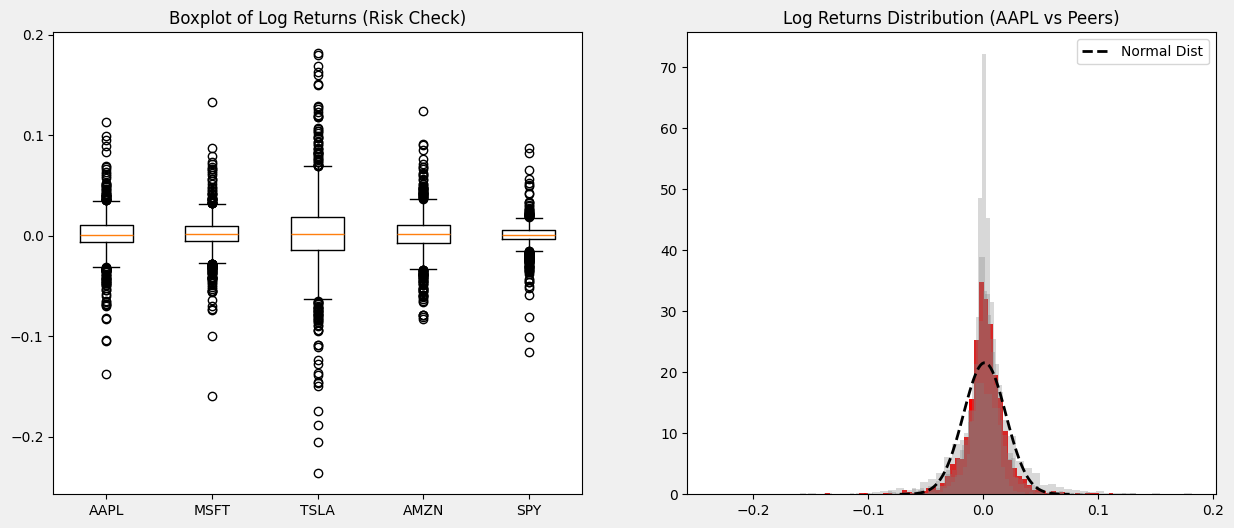

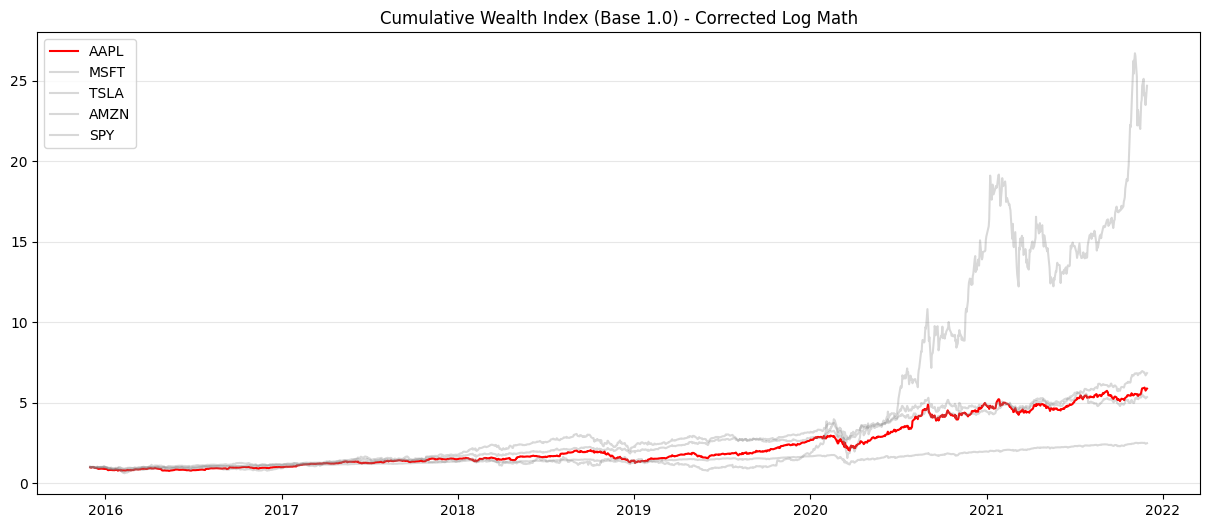

In [26]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

# 1. 预设颜色和样式
colors = {ticker: "grey" if ticker != "AAPL" else "red" for ticker in log_rets.keys()}
alphas = {ticker: 0.3 if ticker != "AAPL" else 1.0 for ticker in log_rets.keys()}

# --- 第一组图：统计分布 ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6), facecolor='#f0f0f0')

# Apple 的统计参数
aapl_rets = log_rets["AAPL"].dropna()
mu, sigma = aapl_rets.mean(), aapl_rets.std()

# 右图：直方图 (使用 Density=True 修复量纲)
for ticker, rets in log_rets.items():
    ax[1].hist(rets.dropna(), bins=60, color=colors[ticker], alpha=alphas[ticker], density=True)

# 叠加正态分布曲线进行对比
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
ax[1].plot(x, st.norm.pdf(x, mu, sigma), lw=2, color="black", linestyle="--", label="Normal Dist")

# 左图：修复为收益率的箱线图
rets_data = [log_rets[t].dropna() for t in log_rets.keys()]
ax[0].boxplot(rets_data, labels=log_rets.keys())
ax[0].set_title("Boxplot of Log Returns (Risk Check)")

ax[1].set_title(f"Log Returns Distribution (AAPL vs Peers)")
ax[1].legend()

# --- 第二组图：累积收益 (修复公式) ---
plt.figure(figsize=(15, 6))
for ticker, rets in log_rets.items():
    # 正确的对数收益率累积公式：exp(cumsum(r))
    cumulative_wealth = np.exp(rets.dropna().cumsum())
    plt.plot(cumulative_wealth, color=colors[ticker], alpha=alphas[ticker], label=ticker)

plt.title("Cumulative Wealth Index (Base 1.0) - Corrected Log Math")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Simple Regressions

In [27]:
PERCENTAGE = .995
WINDOW = 2
PREDICTION_SCOPE = 0

In [28]:
_aapl_raw = yf.download("AAPL", auto_adjust=False)
if isinstance(_aapl_raw.columns, pd.MultiIndex):
    _aapl_raw.columns = _aapl_raw.columns.get_level_values(0)
stock_prices = _aapl_raw

_spy_raw = yf.download("SPY", start="2001-11-30", auto_adjust=False)
if isinstance(_spy_raw.columns, pd.MultiIndex):
    _spy_raw.columns = _spy_raw.columns.get_level_values(0)
SPY = _spy_raw["Close"]

print(f"stock_prices columns: {list(stock_prices.columns)}")
print(f"SPY type: {type(SPY)}, shape: {SPY.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

stock_prices columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
SPY type: <class 'pandas.core.series.Series'>, shape: (6110,)


In [29]:
_aapl_raw = yf.download("AAPL", start="2001-11-30", auto_adjust=False)
if isinstance(_aapl_raw.columns, pd.MultiIndex):
    _aapl_raw.columns = _aapl_raw.columns.get_level_values(0)
stock_prices = _aapl_raw

[*********************100%***********************]  1 of 1 completed


In [30]:
stock_prices = feature_engineering(stock_prices, SPY)

No model yet
  [FeatureEngineer] price col → Adj Close | shape (6110, 6)


In [31]:
train_reg, test_reg = train_test_split(stock_prices, WINDOW)
train_split_reg, validation_split_reg = train_validation_split(train_reg, PERCENTAGE)

In [32]:
print(train_reg.shape)
print(test_reg.shape)

(6005, 38)
(2, 38)


In [33]:
train_set_reg = np.array(train_split_reg)
validation_set_reg = np.array(validation_split_reg)

In [34]:
X_train_reg, y_train_reg, X_val_reg, y_val_reg = windowing(train_set_reg, validation_set_reg, WINDOW, PREDICTION_SCOPE)

In [35]:
#Reshaping the Data

X_train_reg = np.array(X_train_reg)
y_train_reg = np.array(y_train_reg)


X_val_reg = np.array(X_val_reg)
y_val_reg = np.array(y_val_reg)



X_train_reg = X_train_reg.reshape(X_train_reg.shape[0], -1)
X_val_reg = X_val_reg.reshape(X_val_reg.shape[0], -1)

In [36]:
print(y_train_reg.shape)
print(X_train_reg.shape)
print(X_val_reg.shape)
print(y_val_reg.shape)

(5972,)
(5972, 74)
(29, 74)
(29,)


In [37]:
X_test_reg = np.array(test_reg.iloc[:, :-1])
y_test_reg = np.array(test_reg.iloc[:, -1])

print(X_test_reg.shape)

(2, 37)


In [38]:
X_test_reg = X_test_reg.reshape(1, -1)

print(X_test_reg.shape)

(1, 74)


### Linear Regression

In [39]:
lr = LinearRegression()

lr.fit(X_train_reg, y_train_reg)

y_hat_lr= lr.predict(X_val_reg)

mae_lr = mean_absolute_error(y_val_reg, y_hat_lr)

print("MSE: {}".format(np.mean((y_hat_lr-y_val_reg)**2)))
print("MAE: {}".format(mae_lr))

MSE: 29.606839742847885
MAE: 4.041680294225651


### Random Forest Regressor

In [40]:
rf = RandomForestRegressor()

rf.fit(X_train_reg, y_train_reg)

y_hat_rf= rf.predict(X_val_reg)

mae_rf= mean_absolute_error(y_val_reg, y_hat_rf)

print("MSE: {}".format(np.mean((y_hat_rf-y_val_reg)**2)))
print("MAE: {}".format(mae_rf))

MSE: 41.74846747845839
MAE: 5.116462754874396


In [41]:
y_hat_rf = np.ravel(y_hat_rf)
y_hat_lr = np.ravel(y_hat_lr)
y_val_reg = np.ravel(y_val_reg)

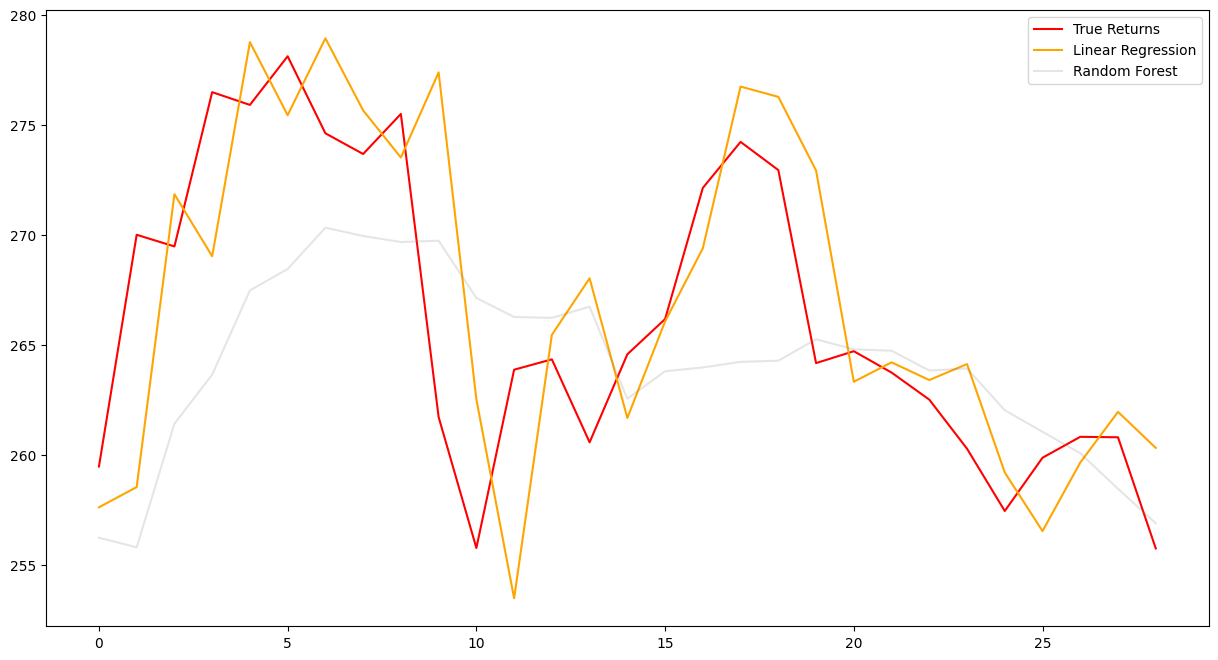

In [42]:
fig,ax = plt.subplots(figsize=(15,8))

ax.plot(y_val_reg, color="red")
ax.plot(y_hat_lr, color="orange")
ax.plot(y_hat_rf, color="grey", alpha=.2)

ax.legend(["True Returns", "Linear Regression", "Random Forest"])

In [43]:
pred_test_lr = lr.predict(X_test_reg)

Window: 2 | Horizon: 1d | Prediction: 252.45$ | MAE: ±4.04


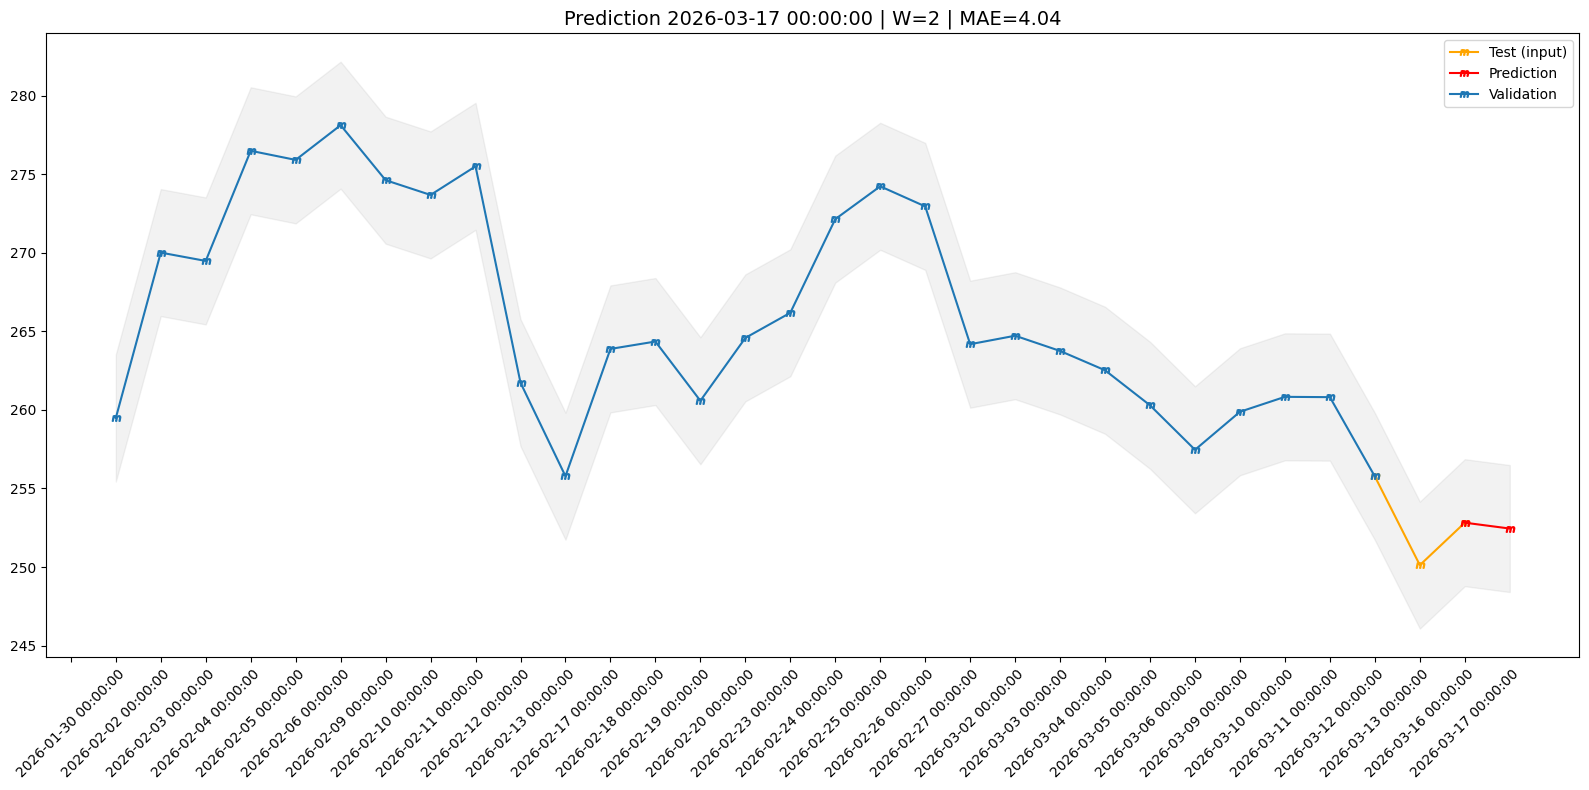

----------------------------------------------------------------------


In [44]:
plotting(y_val_reg, y_test_reg, pred_test_lr, mae_lr, WINDOW, PREDICTION_SCOPE)

# XGBoost

XGBoost, is one of the most highly used supervised ML algorithms nowadays.

The algorithm uses a more optimized way to implement a tree based algorithm.

The methodology followed by this algorithm is the following. XGBoost uses a Greedy algorithm for the building of its tree, meaning it uses a simple intuitive way to optimze the algorithm. This is done by making a prediction (which acts as a threshols), before starting to evaluate the rest of the observations, which then turn into other thresholds, and so on.

This methods enables it to manage huge amount of data very quickly.

In the case of regression, it basically build up a Regression Tree through the residuals of each data point to the initial prediction. Then we split the data into portions and compare one to another and see which one is better at splitting the residuals into clusters of similar values.

For more insights into how this algorithm works, check out this video from [StatQuest](https://www.youtube.com/watch?v=OtD8wVaFm6E&t=649s)


## Feature Engineering

We will firt make the analysis forecasting 1 period ahead

In [45]:
stock_prices = yf.download("AAPL", start="2001-11-30")

[*********************100%***********************]  1 of 1 completed


In [46]:
PERCENTAGE = .995
WINDOW = 2
PREDICTION_SCOPE = 0

In [47]:
stock_prices = feature_engineering(stock_prices, SPY)

No model yet
  [FeatureEngineer] price col → Close | shape (6110, 5)


In [48]:
train, test = train_test_split(stock_prices, WINDOW)
train_set, validation_set = train_validation_split(train, PERCENTAGE)

print(f"train_set shape: {train_set.shape}")
print(f"validation_set shape: {validation_set.shape}")
print(f"test shape: {test.shape}")

train_set shape: (5974, 38)
validation_set shape: (31, 38)
test shape: (2, 38)


Here are some functions that pretend to ease us the work while applying the same algorithm on different period forecasts

In [49]:
X_train, y_train, X_val, y_val = windowing(train_set, validation_set, WINDOW, PREDICTION_SCOPE)

#Convert the returned list into arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (5972, 2, 37)
y_train shape: (5972,)
X_val shape: (29, 2, 37)
y_val shape: (29,)


In [50]:
#Reshaping the Data

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (5972, 74)
X_val shape: (29, 74)


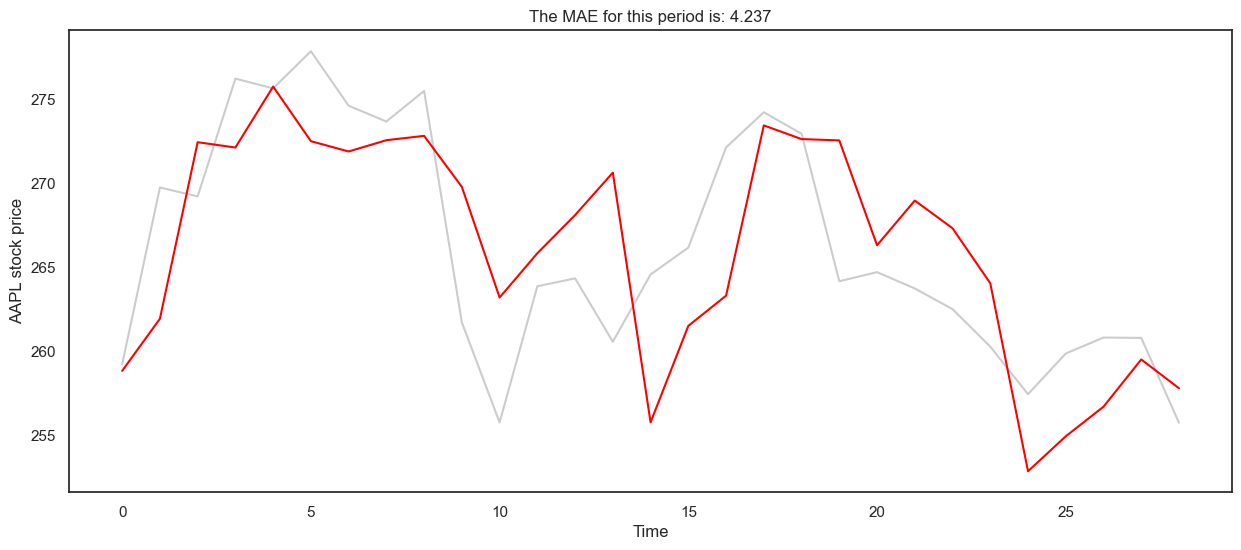

In [51]:
mae, xgb_model = xgb_model(X_train, y_train, X_val, y_val, plotting=True)

<Figure size 1600x1600 with 0 Axes>

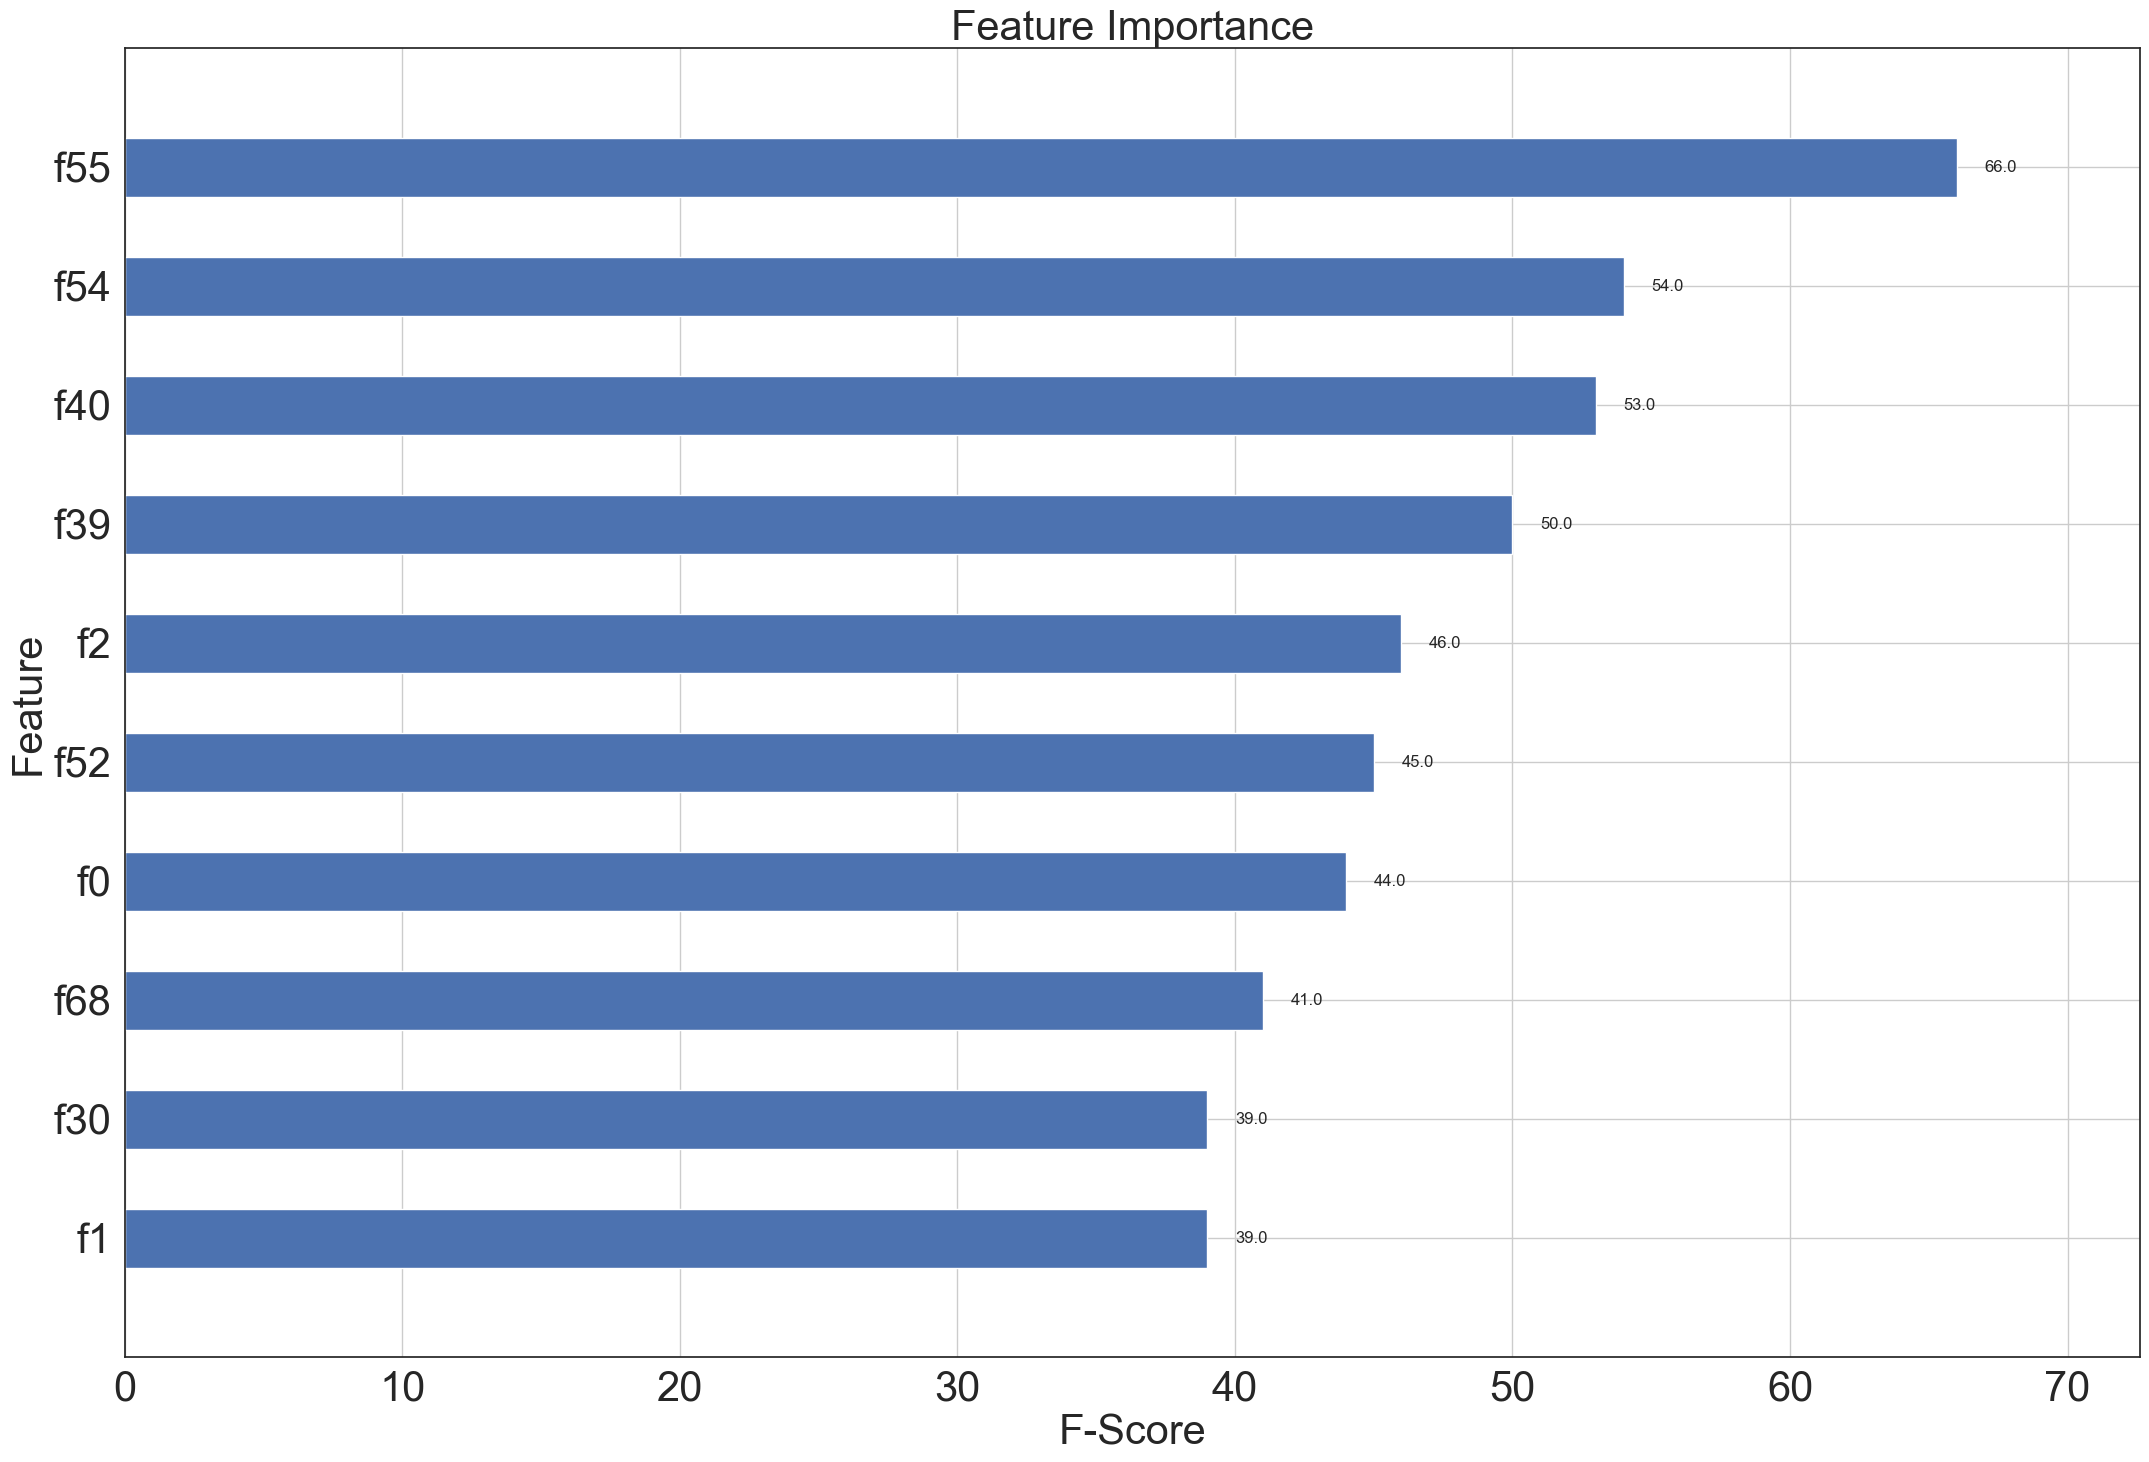

In [52]:
plt.figure(figsize=(16, 16))
fig, ax = plt.subplots(1, 1, figsize=(26, 17))

plot_importance(xgb_model,ax=ax,height=0.5, max_num_features=10)
ax.set_title("Feature Importance", size=30)
plt.xticks(size=30)
plt.yticks(size=30)
plt.ylabel("Feature", size=30)
plt.xlabel("F-Score", size=30)
plt.show()

## Add the predictions (if needed)

In [53]:
#try:
    #y_hat_train = np.expand_dims(xgb_model.predict(X_train), 1)
    #array = np.empty((stock_prices.shape[0]-y_hat_train.shape[0], 1))
    #array[:] = np.nan
    #predictions = np.concatenate((array, y_hat_train))
#except NameError:
    #print("No Model")
    
    
#new_stock_prices = feature_engineering(stock_prices, SPY, predictions=predictions)


#train, test = train_test_split(new_stock_prices, WINDOW)

#train_set, validation_set = train_validation_split(train, PERCENTAGE)
#X_train, y_train, X_val, y_val = windowing(train_set, validation_set, WINDOW, PREDICTION_SCOPE)

#Reshaping the data
#X_train = np.array(X_train)
#y_train = np.array(y_train)

#X_val = np.array(X_val)
#y_val = np.array(y_val)

#X_train = X_train.reshape(X_train.shape[0], -1)
#X_val = X_val.reshape(X_val.shape[0], -1)


#new_mae, new_xgb_model = xgb_model(X_train, y_train, X_val, y_val, plotting=True)

#print(new_mae)

## Evaluation on the Test Set

In [54]:
X_test = np.array(test.iloc[:, :-1])
y_test = np.array(test.iloc[:, -1])
X_test = X_test.reshape(1, -1)

print(f"X_test shape: {X_test.shape}")

X_test shape: (1, 74)


In [55]:
#Apply the xgboost model on the Test Data

pred_test_xgb = xgb_model.predict(X_test)

Window: 2 | Horizon: 1d | Prediction: 258.01$ | MAE: ±4.24


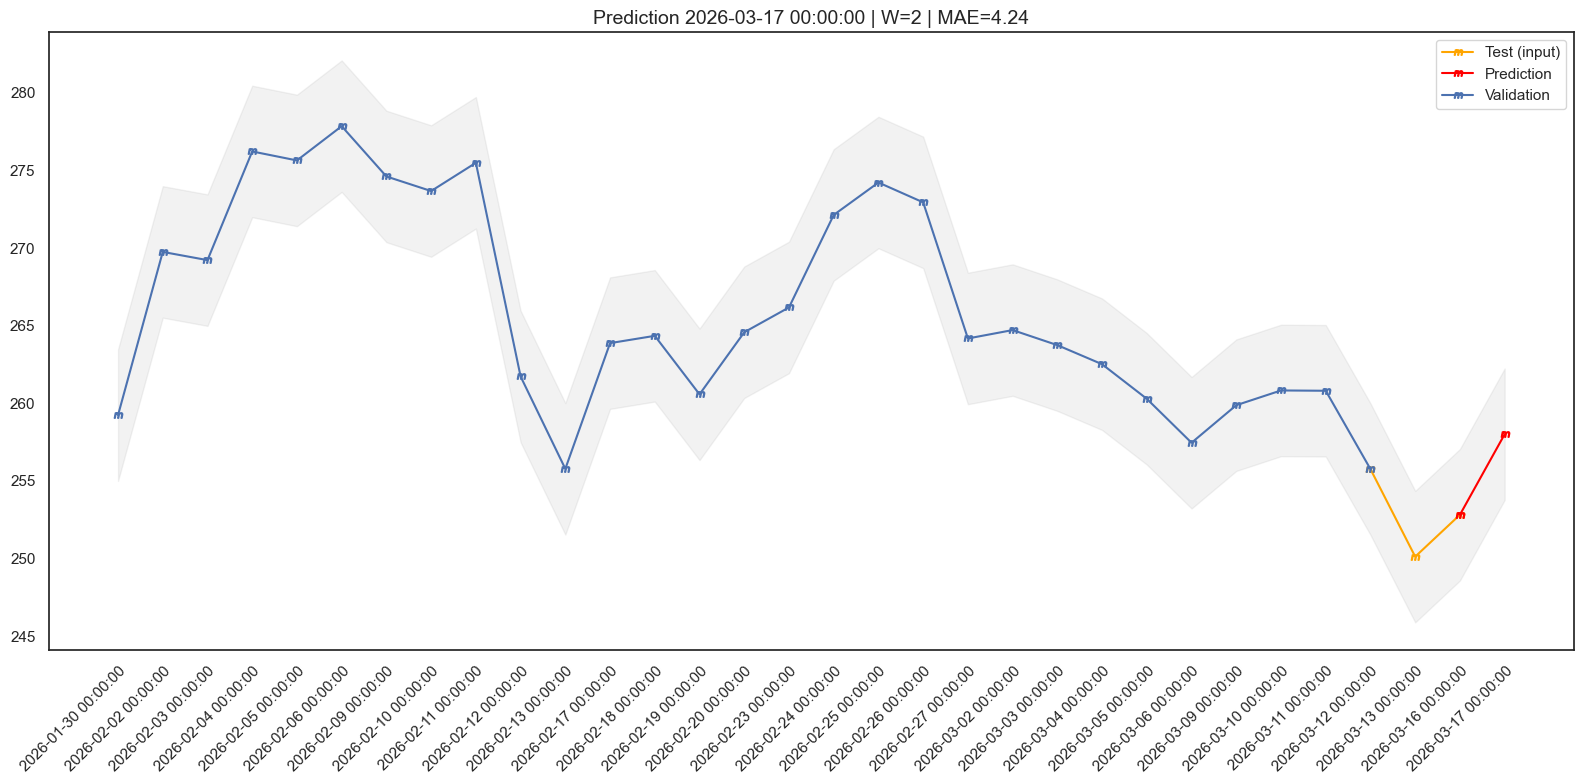

----------------------------------------------------------------------


In [56]:
plotting(y_val, y_test, pred_test_xgb, mae, WINDOW, PREDICTION_SCOPE)

## Saving the XGBoost parameters

In [57]:
#joblib.dump(xgb_model, "XGBoost.pkl")

## MULTIPLE EVALUATIONS

In [58]:
plots = {}


for window in [1, 2, 3, 4, 5, 6, 7, 10, 20, 25, 30, 35]:
    
    for percentage in [.92, .95, .97, .98, .99, .995]:

        WINDOW = window
        pred_scope = 0
        PREDICTION_SCOPE = pred_scope
        PERCENTAGE = percentage

        train = stock_prices.iloc[:int(len(stock_prices))-WINDOW]
        test = stock_prices.iloc[-WINDOW:]
        
        train_set, validation_set = train_validation_split(train, PERCENTAGE)

        X_train, y_train, X_val, y_val = windowing(train_set, validation_set, WINDOW, PREDICTION_SCOPE)

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        X_val = np.array(X_val)
        y_val = np.array(y_val)

        X_test = np.array(test.iloc[:, :-1])
        y_test = np.array(test.iloc[:, -1])

        X_train = X_train.reshape(X_train.shape[0], -1)
        try:
            X_val = X_val.reshape(X_val.shape[0], -1)
            X_test = X_test.reshape(1, -1)
        except ValueError:
            break

        xgb_model = xgb.XGBRegressor(gamma=1)
        xgb_model.fit(X_train, y_train)

        pred_val = xgb_model.predict(X_val)

        mae = mean_absolute_error(y_val, pred_val)

        pred_test = xgb_model.predict(X_test)
        plotii= [y_test[-1], pred_test]

        plots[str(window)+str(pred_scope)] = [y_val, y_test, pred_test, mae, WINDOW, PREDICTION_SCOPE, PERCENTAGE]
    

In [59]:
print()
print(plots["20"])
print("-----------------------------------------------------------------------------------------------------------------")
print(plots["10"])


[array([259.23742676, 269.75759888, 269.22808838, 276.23150635,
       275.65206909, 277.85998535, 274.61999512, 273.67999268,
       275.5       , 261.73001099, 255.77999878, 263.88000488,
       264.3500061 , 260.57998657, 264.57998657, 266.17999268,
       272.14001465, 274.23001099, 272.95001221, 264.17999268,
       264.72000122, 263.75      , 262.51998901, 260.29000854,
       257.45999146, 259.88000488, 260.82998657, 260.80999756,
       255.75999451]), array([250.11999512, 252.82000732]), array([258.01004], dtype=float32), 4.236706437735722, 2, 0, 0.995]
-----------------------------------------------------------------------------------------------------------------
[array([259.23742676, 269.75759888, 269.22808838, 276.23150635,
       275.65206909, 277.85998535, 274.61999512, 273.67999268,
       275.5       , 261.73001099, 255.77999878, 263.88000488,
       264.3500061 , 260.57998657, 264.57998657, 266.17999268,
       272.14001465, 274.23001099, 272.95001221, 264.17999268,


In [60]:
window_optimization(plots)

([[array([269.75759888, 269.22808838, 276.23150635, 275.65206909,
          277.85998535]),
   array([274.61999512, 273.67999268, 275.5       , 261.73001099,
          255.77999878, 263.88000488, 264.3500061 , 260.57998657,
          264.57998657, 266.17999268, 272.14001465, 274.23001099,
          272.95001221, 264.17999268, 264.72000122, 263.75      ,
          262.51998901, 260.29000854, 257.45999146, 259.88000488,
          260.82998657, 260.80999756, 255.75999451, 250.11999512,
          252.82000732]),
   array([265.754], dtype=float32),
   3.06949462890625,
   25,
   0,
   0.995]],
 ['250'])

Window: 1 | Horizon: 1d | Prediction: 254.14$ | MAE: ±5.61


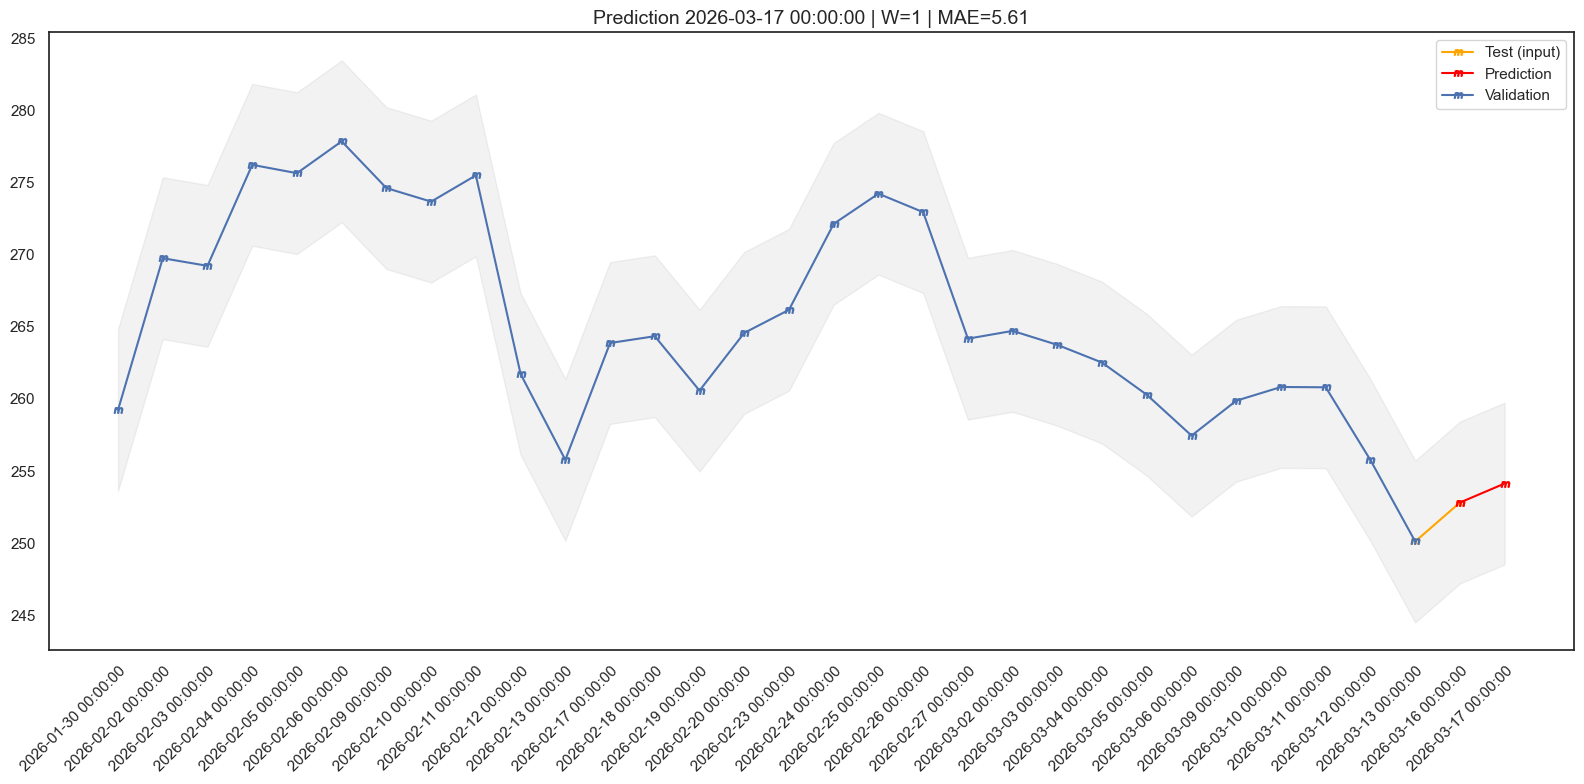

----------------------------------------------------------------------
Window: 2 | Horizon: 1d | Prediction: 258.01$ | MAE: ±4.24


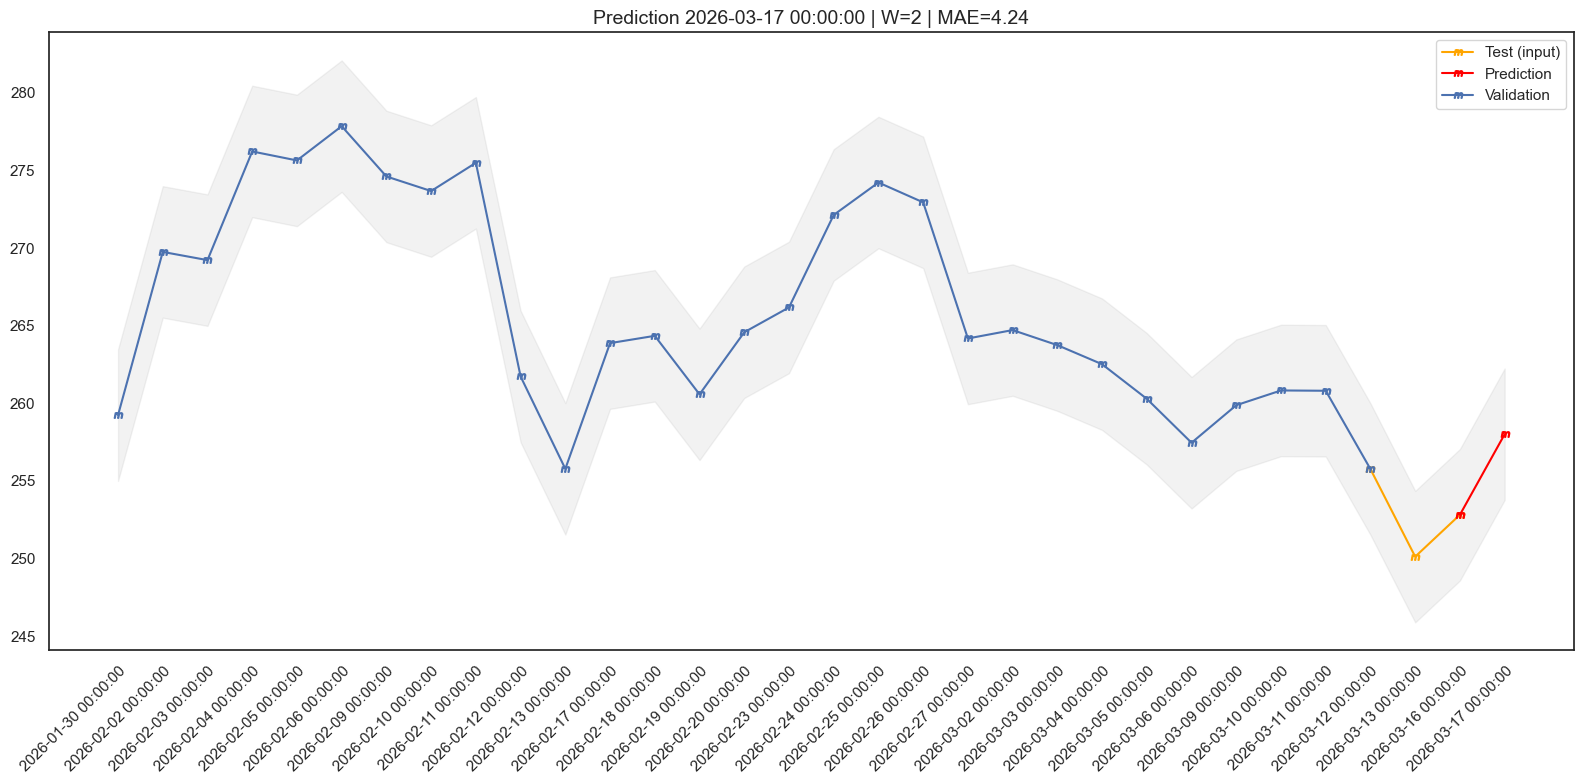

----------------------------------------------------------------------
Window: 3 | Horizon: 1d | Prediction: 254.04$ | MAE: ±4.81


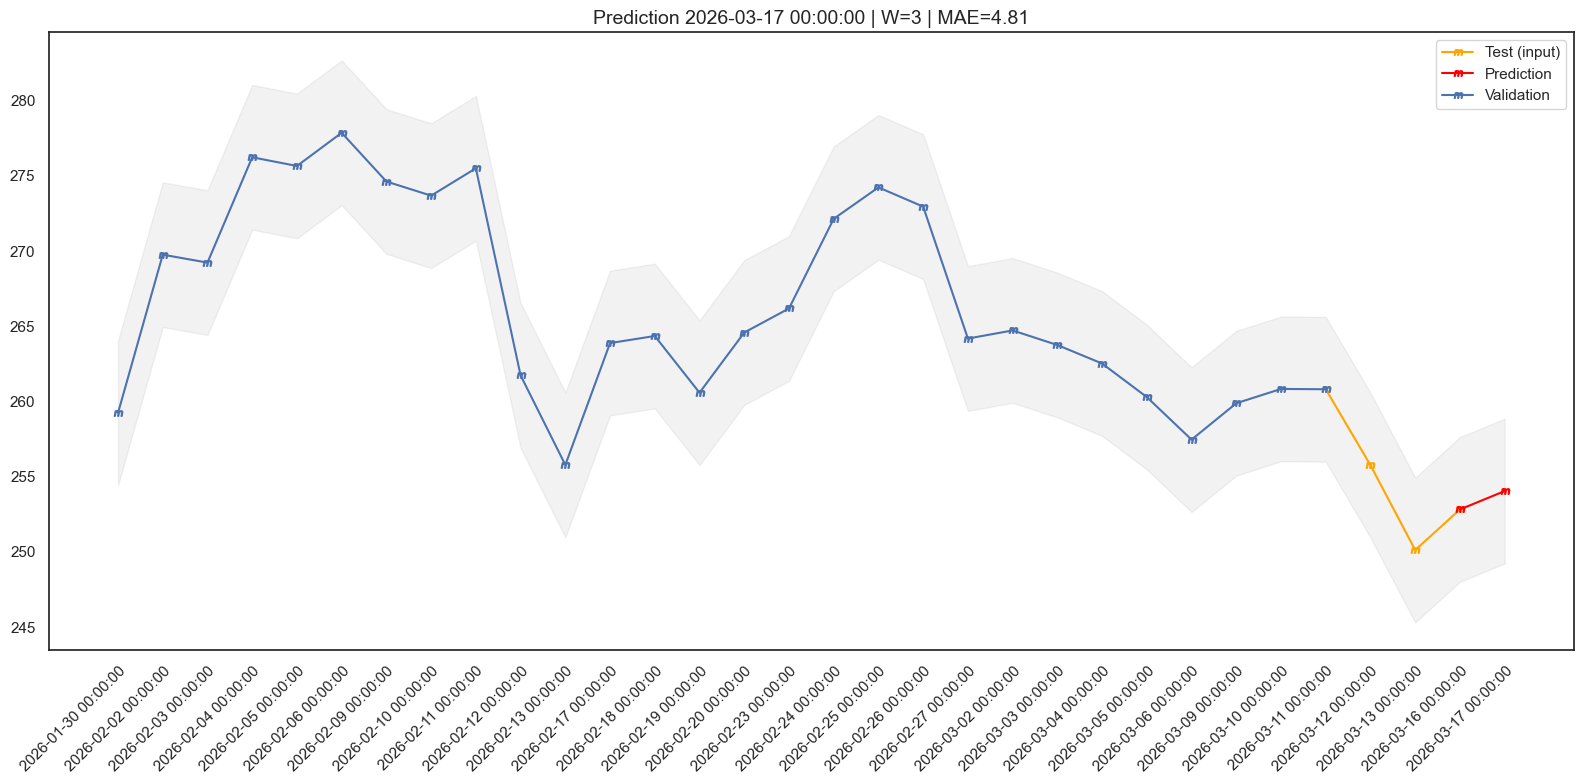

----------------------------------------------------------------------
Window: 4 | Horizon: 1d | Prediction: 253.87$ | MAE: ±5.2


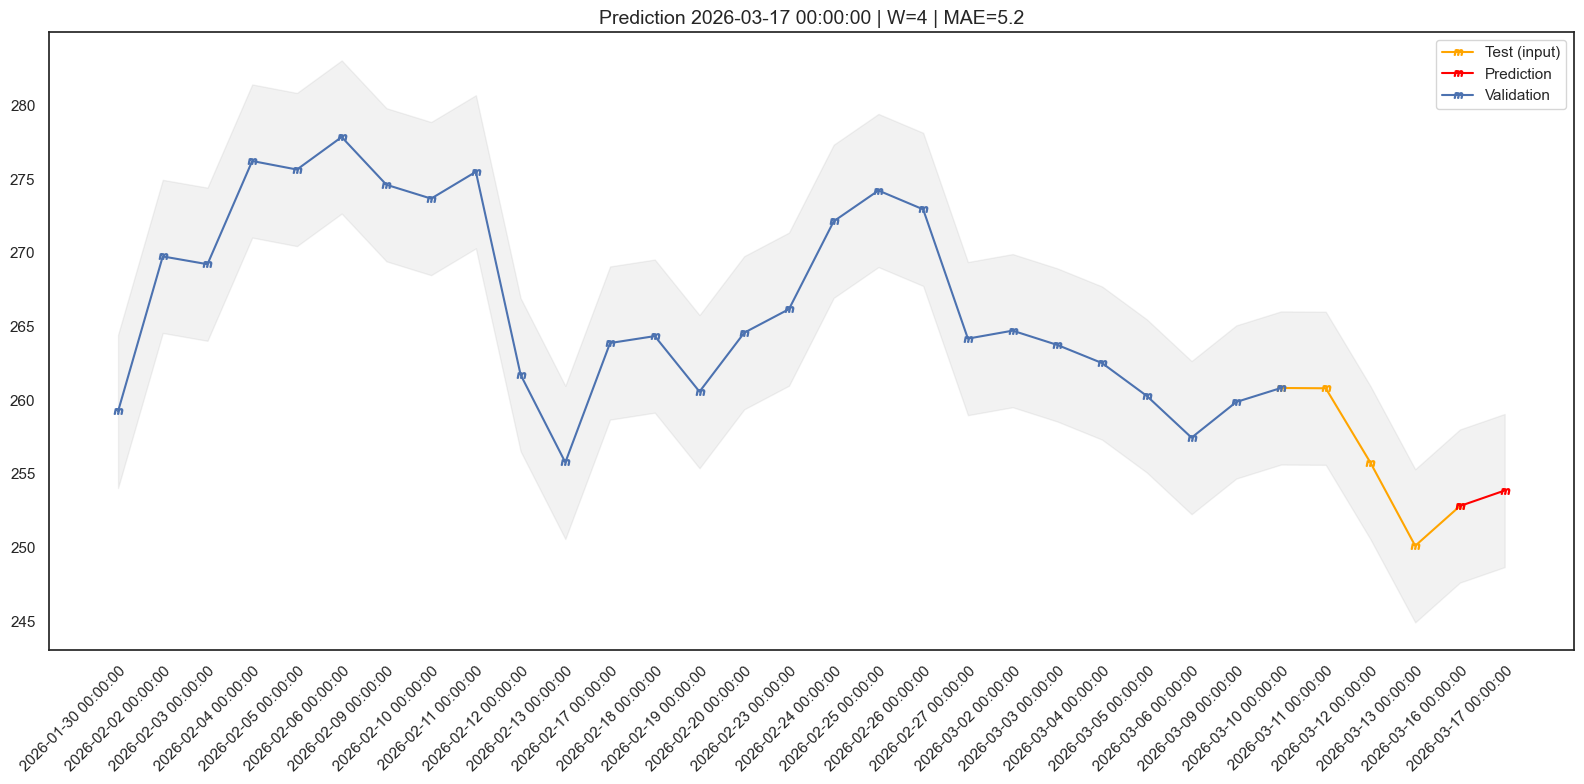

----------------------------------------------------------------------
Window: 5 | Horizon: 1d | Prediction: 251.77$ | MAE: ±4.47


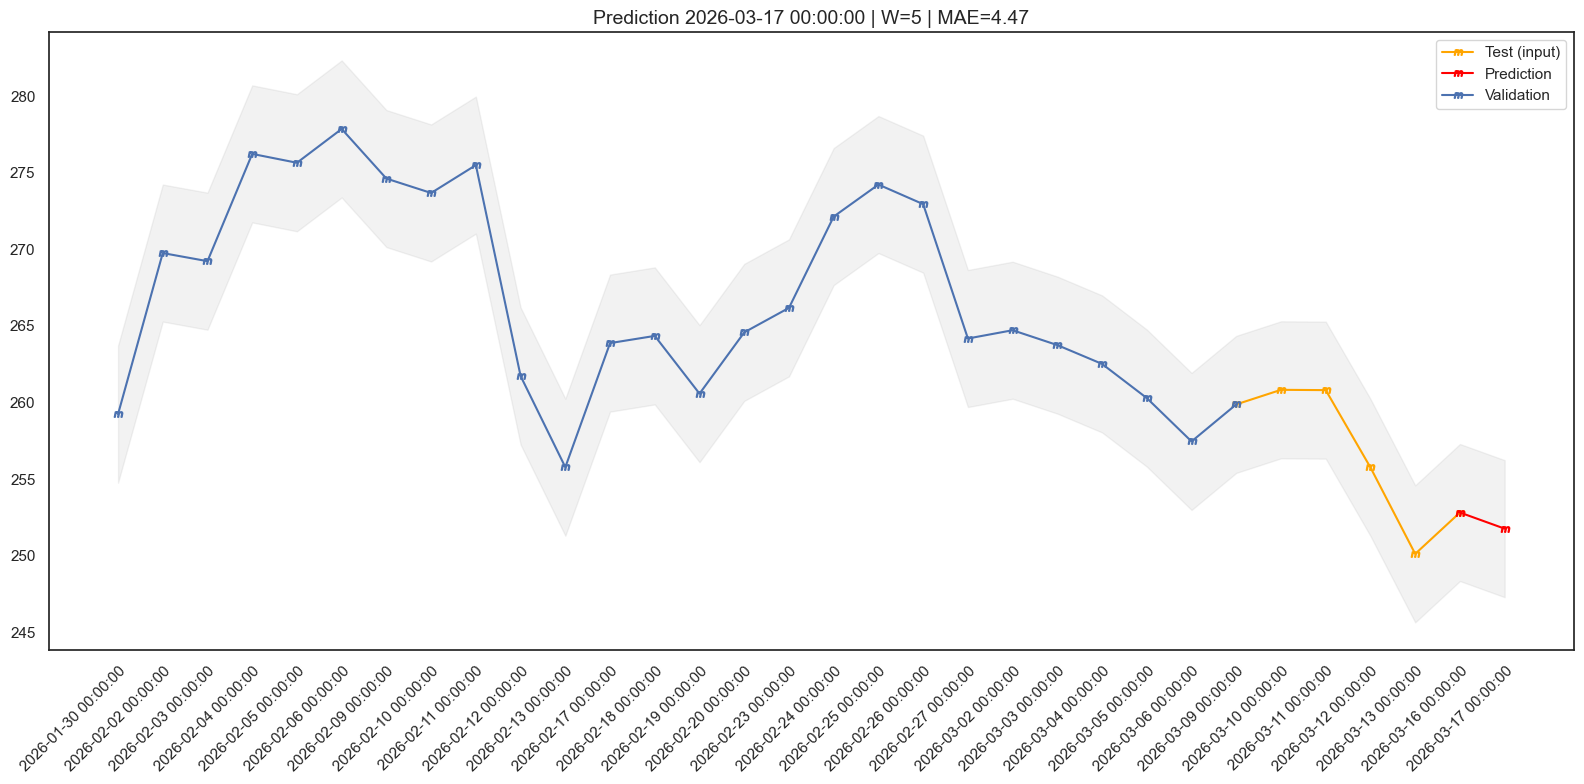

----------------------------------------------------------------------
Window: 6 | Horizon: 1d | Prediction: 260.26$ | MAE: ±4.61


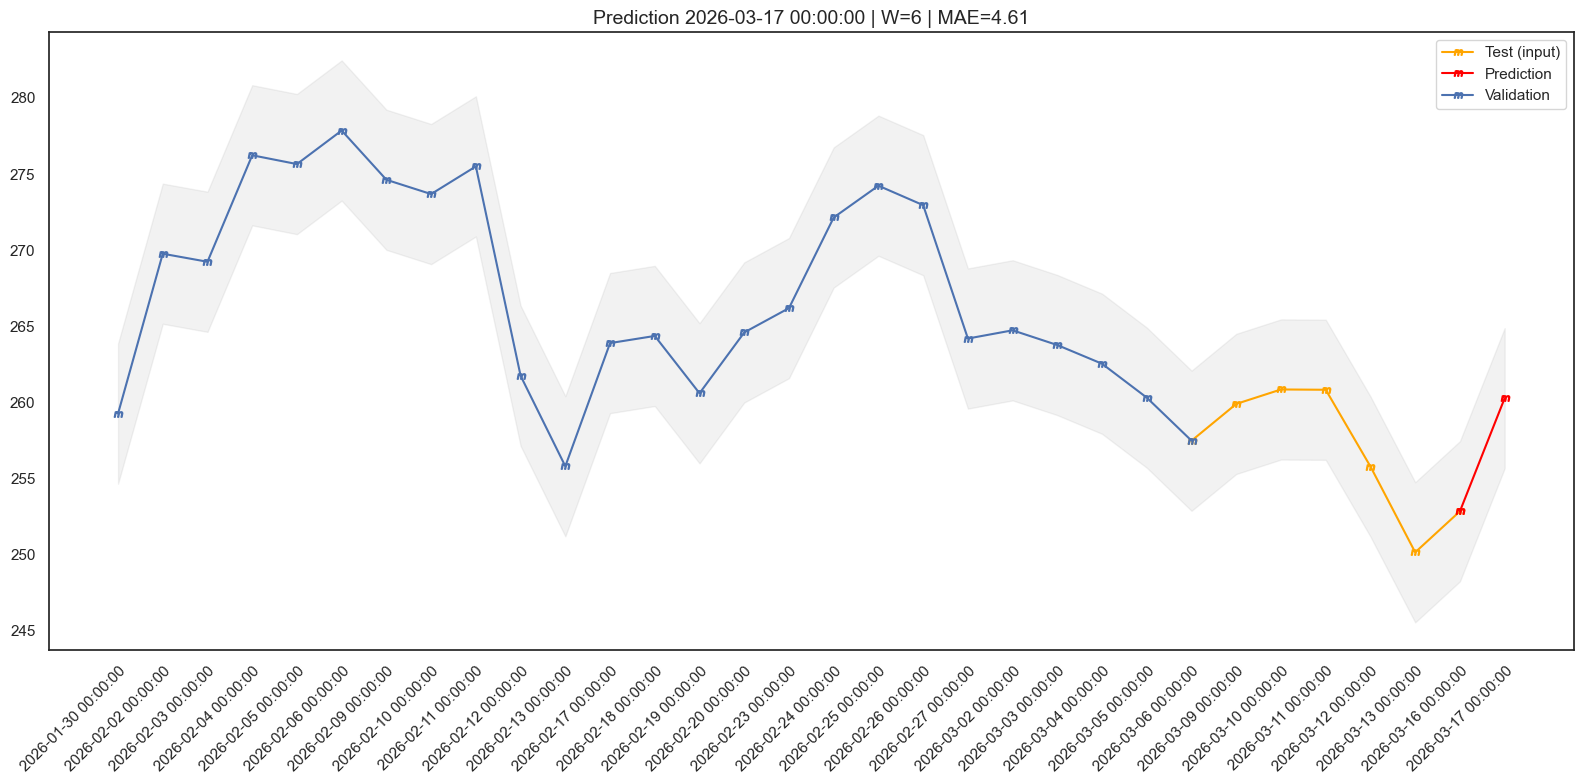

----------------------------------------------------------------------
Window: 7 | Horizon: 1d | Prediction: 253.6$ | MAE: ±5.01


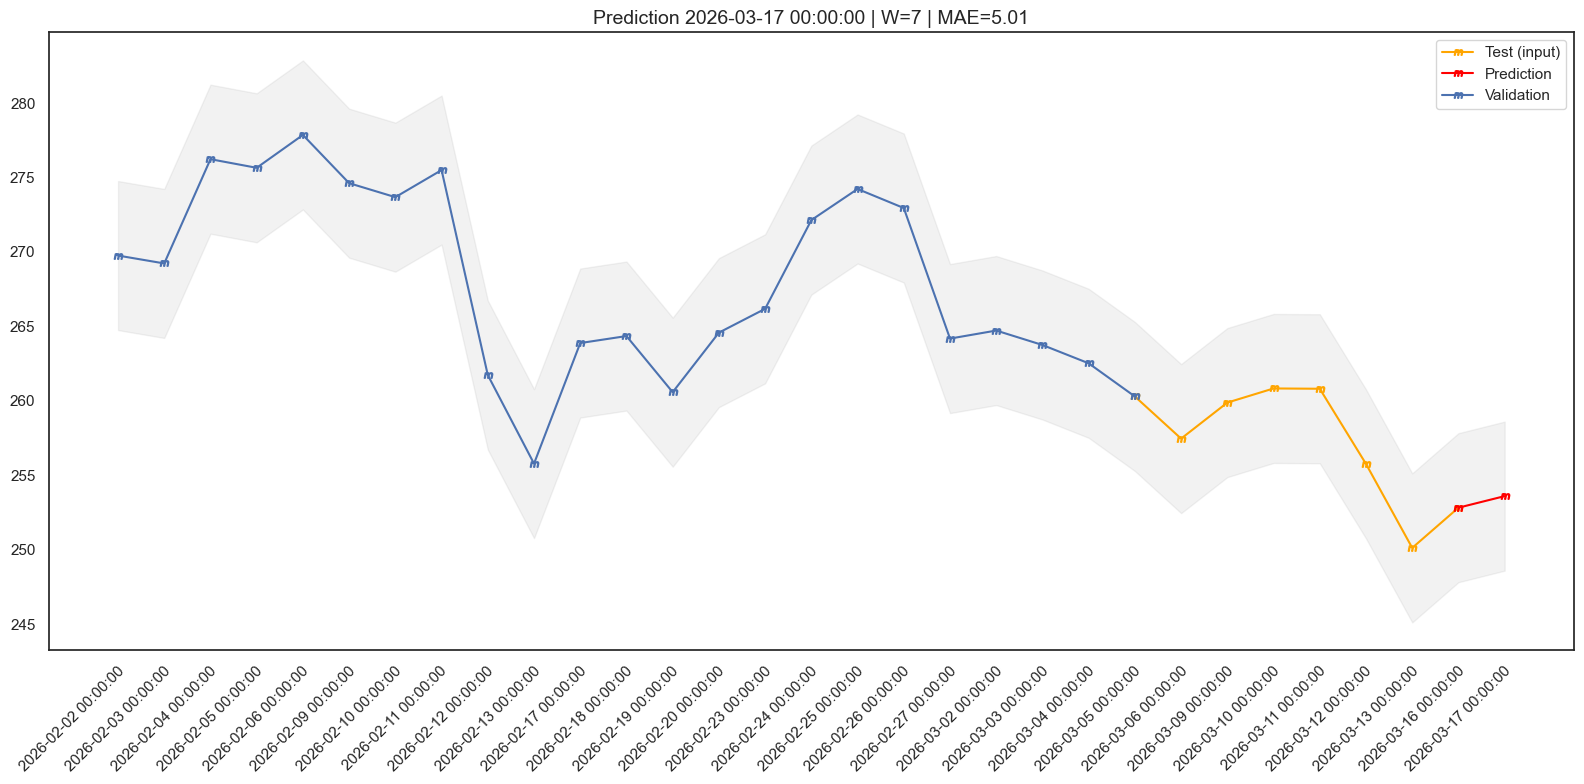

----------------------------------------------------------------------
Window: 10 | Horizon: 1d | Prediction: 259.78$ | MAE: ±5.59


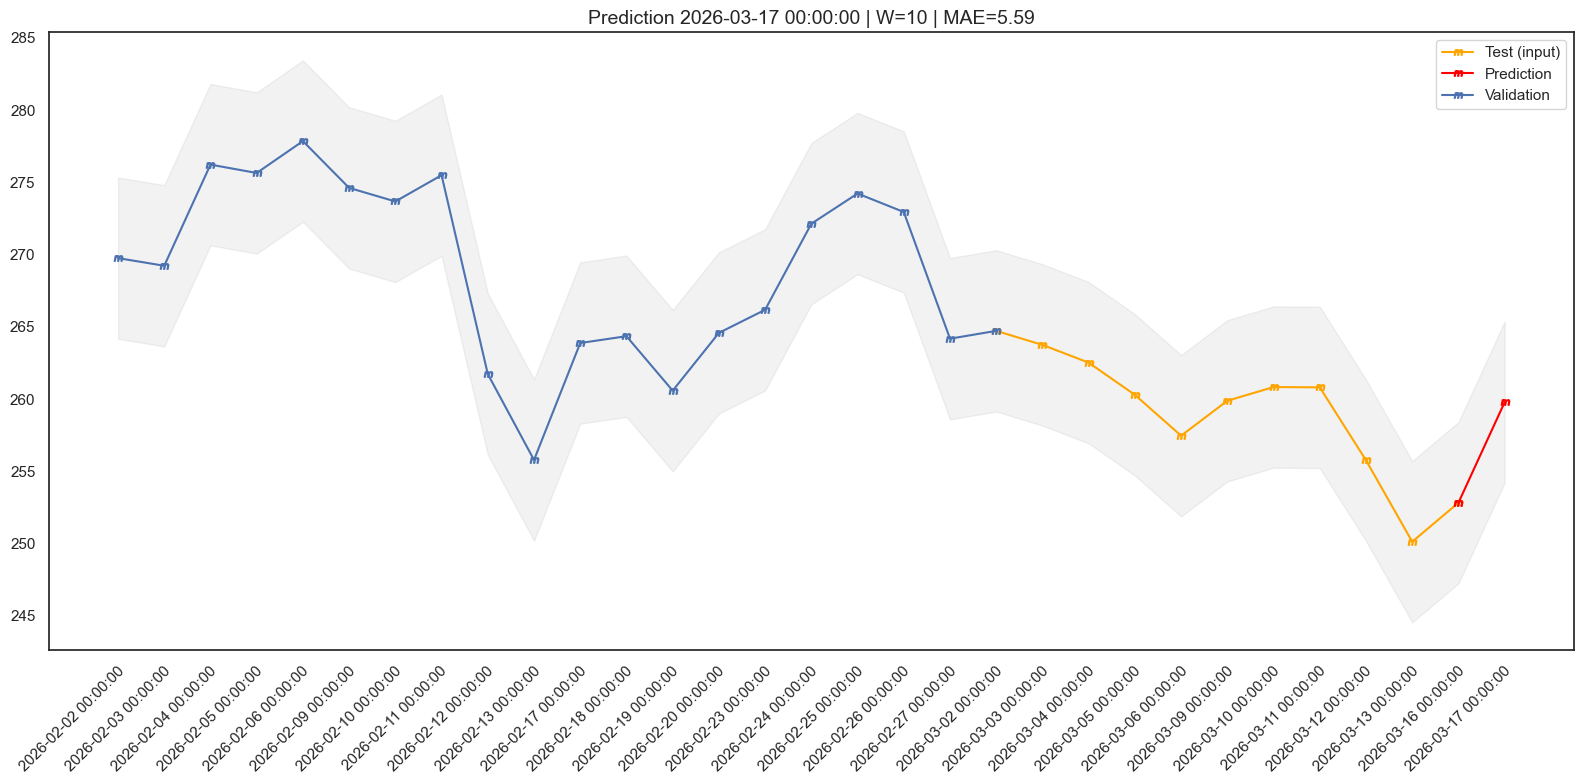

----------------------------------------------------------------------
Window: 20 | Horizon: 1d | Prediction: 264.67$ | MAE: ±8.07


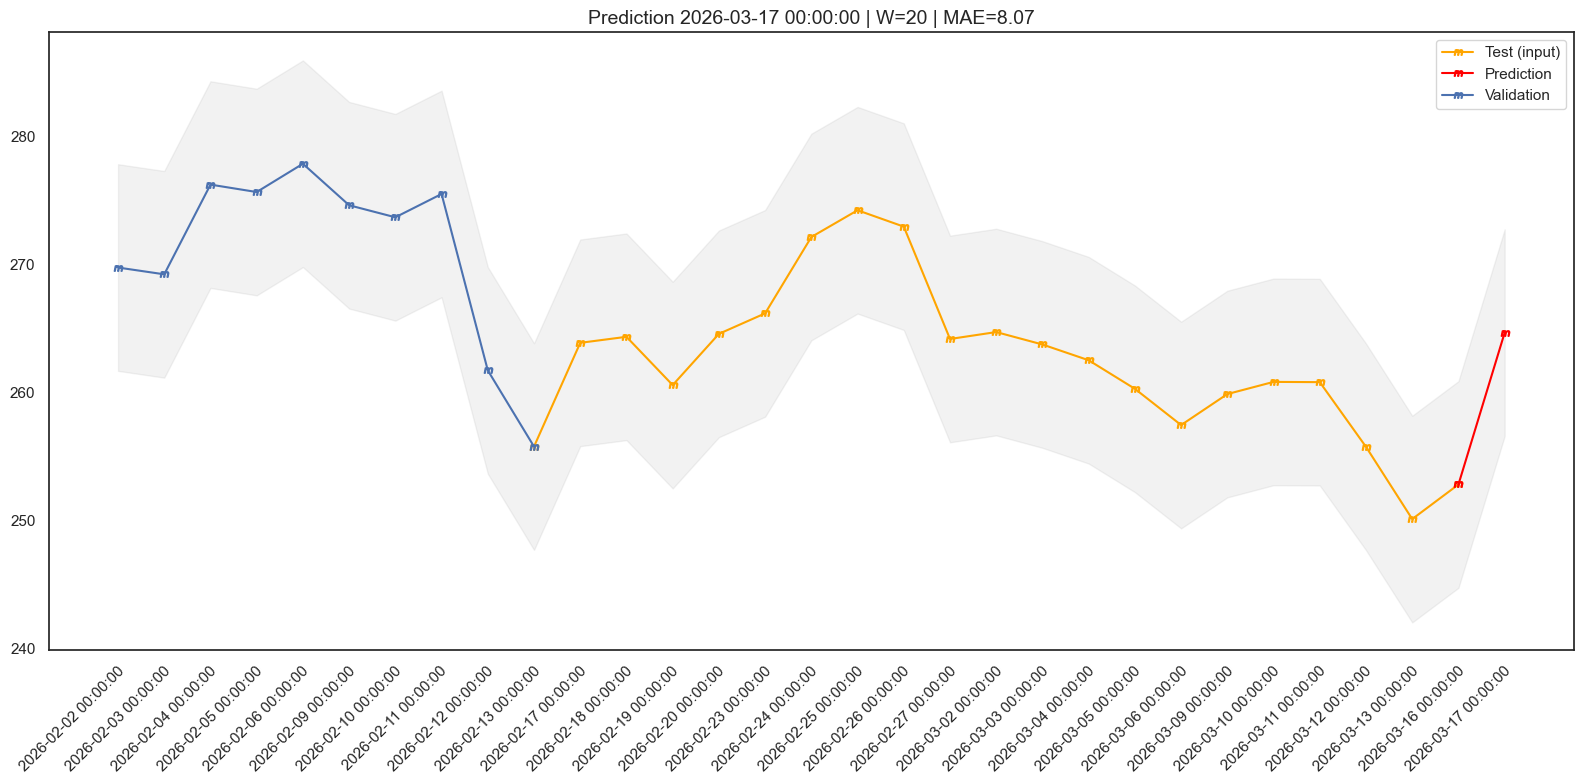

----------------------------------------------------------------------


In [61]:
for key in list(plots.keys())[:9]:
    plotting(plots[key][0], plots[key][1], plots[key][2], plots[key][3], plots[key][4], plots[key][5])

# LSTM


Long Short Term Memory or LSTM is a type of Recurrent Neural Network, which instead fo only processing the information they recieve from the previous neuron and apply the activation function from scratch, they actually divide the neuron into three main parts from which to set up the input from the next layer of neurons: Learn, Unlearn and Retain gate.

The idea behind this method is to ensure that you are using the information given from previous data and the data returned from a neural that is in the same layer, to get the input for the next nuron.

This is specially usefull, when you are relying on the temporal distribution of the data, i.e. text, time series mainly.

In this work we will see how the LSTM is used for predicting the next period from Apple stock. Through hyperparameter tuning there was a need to define, similar to normal RNN, the input and hidden layer size, the batch_size, number of epochs and the rolling window size for the analysis.

The data ranging from 2001 till now, gained from the Yahoo Finance API, got splitted into a train, validation and test set to see how the model performed on different distributions. After that, the test set was settled to be the last width of the input data in order to predict the next period.

The parameters are showed below.

In [62]:
#Parameters for the LSTM
PERCENTAGE = .97 #Split train/val and test set
CALLBACK = .031 #Used to stop training the Network when the MAE from the validation set reached a perormance below 3.1%
BATCH_SIZE = 20 #Number of samples that will be propagated through the network. I chose almost a trading month
EPOCH = 50 #Settled to train the model
WINDOW_LSTM = 30 #The window used for the input data
PREDICTION_SCOPE = 0 #How many period to predict, being 0=1

In [63]:
train_lstm, test_lstm = train_test_split(stock_prices, WINDOW_LSTM)
train_split_lstm, validation_split_lstm = train_validation_split(train_lstm, PERCENTAGE)

train_split_lstm = np.array(train_split_lstm)
validation_split_lstm = np.array(validation_split_lstm)


## Rescaling to train the LSTM

In [64]:
scaler = MinMaxScaler()
scaler.fit(train_split_lstm)

train_scale_lstm = scaler.transform(train_split_lstm)
val_scale_lstm = scaler.transform(validation_split_lstm)
test_scale_lstm = scaler.transform(test_lstm)

print(train_scale_lstm.shape)
print(val_scale_lstm.shape)
print(test_scale_lstm.shape)

(5797, 38)
(180, 38)
(30, 38)


In [65]:
X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm = windowing(train_scale_lstm, val_scale_lstm, WINDOW_LSTM, PREDICTION_SCOPE)

In [66]:

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

X_val_lstm = np.array(X_val_lstm)
y_val_lstm = np.array(y_val_lstm)

X_test_lstm = np.array(test_scale_lstm[:, :-1])
y_test_lstm = np.array(test_scale_lstm[:, -1])

print(X_train_lstm.shape)
print(X_val_lstm.shape)
print(X_test_lstm.shape)

(5767, 30, 37)
(150, 30, 37)
(30, 37)


Epoch 1/50
289/289 [==============================] - 7s 14ms/step - loss: 0.0018 - mae: 0.0267 - val_loss: 0.0013 - val_mae: 0.0439
Epoch 2/50
289/289 [==============================] - 4s 12ms/step - loss: 1.2455e-04 - mae: 0.0110 - val_loss: 0.0018 - val_mae: 0.0523
Epoch 3/50
289/289 [==============================] - 4s 13ms/step - loss: 8.3604e-05 - mae: 0.0088 - val_loss: 8.4769e-04 - val_mae: 0.0346
Epoch 4/50
289/289 [==============================] - 4s 13ms/step - loss: 7.9133e-05 - mae: 0.0086 - val_loss: 0.0011 - val_mae: 0.0402
Epoch 5/50
289/289 [==============================] - 4s 12ms/step - loss: 7.1177e-05 - mae: 0.0081 - val_loss: 0.0017 - val_mae: 0.0512
Epoch 6/50
289/289 [==============================] - 4s 14ms/step - loss: 6.5050e-05 - mae: 0.0076 - val_loss: 8.7041e-04 - val_mae: 0.0350
Epoch 7/50
287/289 [============================>.] - ETA: 0s - loss: 6.2160e-05 - mae: 0.0074
 Accuracy % so cancelling training
289/289 [==============================] - 3

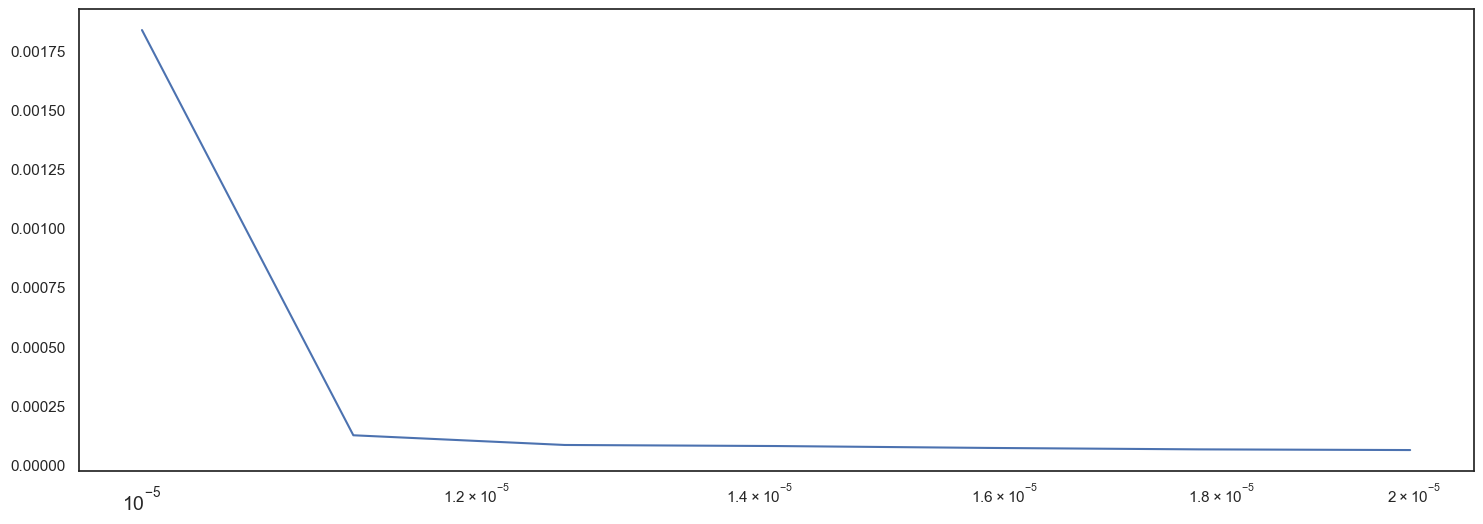

In [67]:
model_lstm = lstm_model(X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, EPOCH, BATCH_SIZE, CALLBACK, plotting=True)


In [68]:
#Set up predictions for train and validation set
y_hat_lstm = model_lstm.predict(X_val_lstm)
y_hat_train_lstm = model_lstm.predict(X_train_lstm)

#Validation Transormation
mae_lstm = mean_absolute_error(y_val_lstm, y_hat_lstm)
real_val, pred_val = inverse_transformation(X_val_lstm, y_val_lstm, y_hat_lstm)
mae_lstm = mean_absolute_error(real_val.iloc[:, -1], pred_val.iloc[:, -1])

181/181 [==============================] - 1s 4ms/step


Text(0.5, 1.0, 'MAE for this period: 6.77')

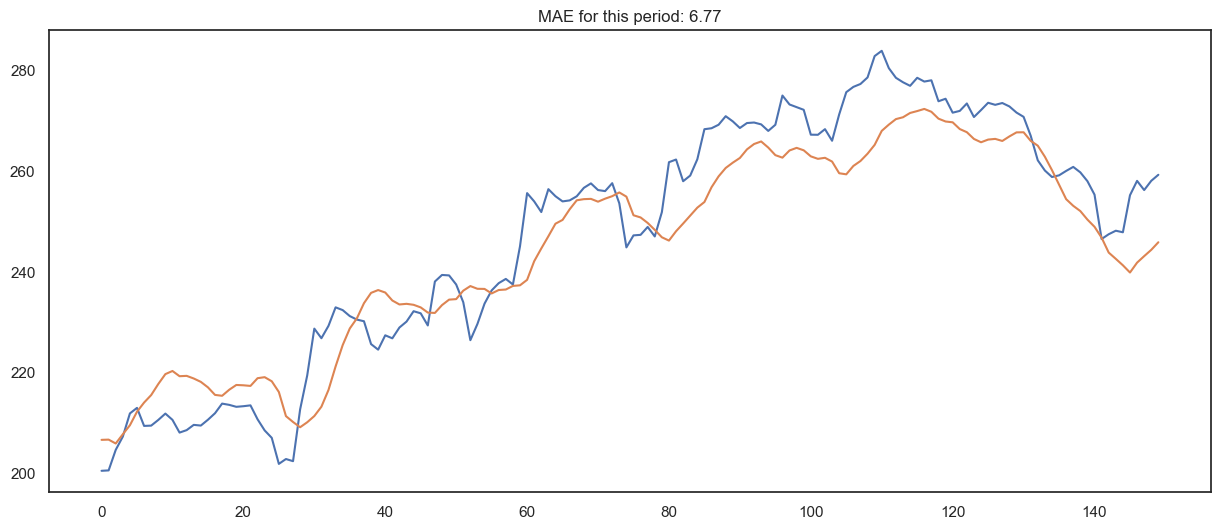

In [69]:
plt.figure(figsize=(15, 6))
plt.plot(real_val.iloc[:, -1])
plt.plot(pred_val.iloc[:, -1])
plt.title(f"MAE for this period: {round(mae_lstm, 2)}")

In [70]:
real_train, pred_train = inverse_transformation(X_train_lstm, y_train_lstm, y_hat_train_lstm)

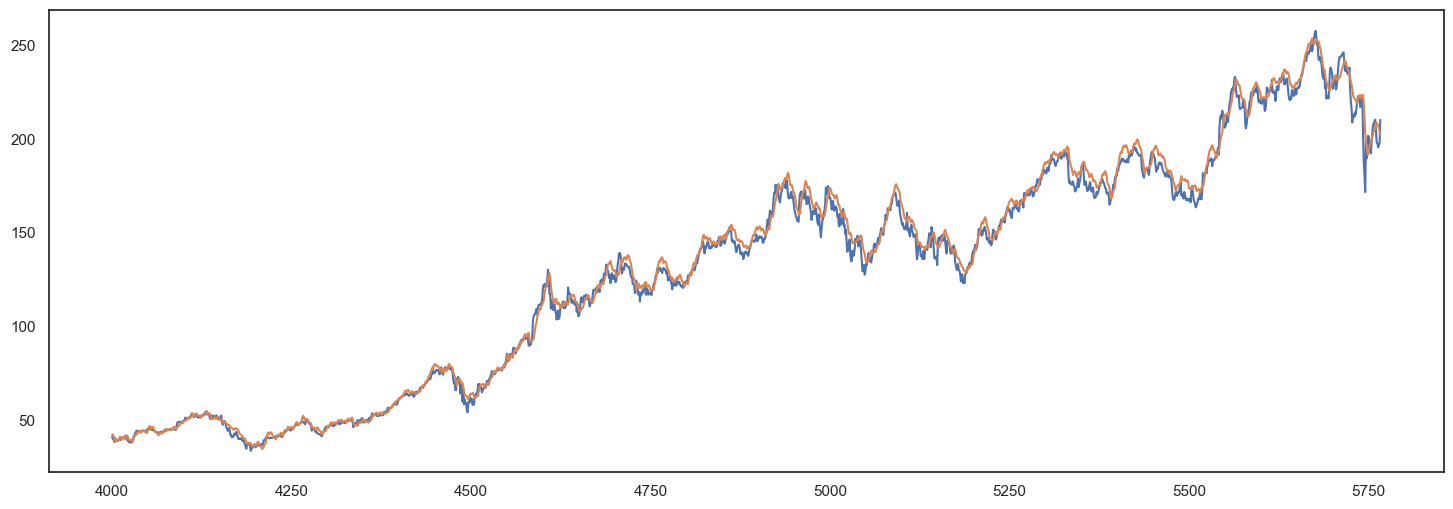

In [71]:
plt.figure(figsize=(18, 6))
plt.plot(real_train.iloc[4000:, -1])
plt.plot(pred_train.iloc[4000:, -1])

## Prediction

In [72]:
X_test_formula = X_test_lstm.reshape(X_test_lstm.shape[0], 1, X_test_lstm.shape[1])

In [73]:
X_test_formula.shape

(30, 1, 37)

In [74]:
X_test_lstm = X_test_formula.reshape(1, X_test_formula.shape[0], X_test_formula.shape[2])

In [75]:
X_test_lstm.shape

(1, 30, 37)

In [76]:
y_hat_test_lstm = model_lstm.predict(X_test_lstm)

1/1 [==============================] - 0s 21ms/step


In [77]:
real_test, pred_test = inverse_transformation(X_test_lstm, y_test_lstm, y_hat_test_lstm)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1 and the array at index 1 has size 30

In [ ]:
y_val_lstm = np.array(real_val.iloc[-30:, 49])
y_test_lstm = np.array(real_test.iloc[:, 49])
pred_test = np.array(pred_test.iloc[-1:, 49])
mae_lstm = mean_absolute_error(real_val.iloc[:, -1], pred_val.iloc[:, -1])

IndexError: single positional indexer is out-of-bounds

In [ ]:
plotting(y_val_lstm, y_test_lstm, pred_test, mae_lstm, WINDOW_LSTM, PREDICTION_SCOPE)

## Saving the Model

In [ ]:
#model.save('./SVM')

In [ ]:
#lstm_model = tf.keras.models.load_model("SVM")

# COMBINATION XGBoost-LSTM


In order to get the most out of the two models, good practice is to combine those two and apply a higher weight on the model which got a lower loss function (mean absolute error).

In our case we saw that the MAE of the XGBoost was lower than the one from the LSTM, therefore we will gave a higher weight on the predictions returned from the XGBoost model.

In [ ]:
mae_xgboost = mae

In [ ]:
pred_test

In [ ]:
pred_test_xgb

In [ ]:
scope = predictions(mae_lstm, mae_xgboost, pred_test_xgb, pred_test)

In [ ]:
avg_mae = (mae_lstm + mae_xgboost)/2